# Q3 : Advanced Leaky Integrate and Fire


$$
\tau \frac{du(t)}{dt} = - \left(u(t) - u_{rest} \right) + \frac{I(t)}{g_L}
$$


Characterstic constant $\tau = 20 ms = 2 \times 10^{-2}s$ </br>
Membrane conductance $g_L = 10 nS = 1 \times 10^{-8} S$ </br>
Resting potential $u_{rest} = -65mV = -65 \times 10^{-3} V$ </br>
Threshold potential $u_{th} = -50mV = -50 \times 10^{-3} V$ </br>
Reset potential $u_{reset} = -65mV = -65 \times 10^{-3} V$ </br>
Refractory Period $t_{ref} = 2 ms = 2 \times 10^{-3}s$ </br>
Simulation timestep $\Delta t = 0.1 ms = 10^{-4}s$


In [3]:
# Basic Libraries
import matplotlib.pyplot as plt
import numpy as np

In [115]:
u_rest = -65 * 1e-3
u_th = -50 * 1e-3
u_reset = -65 * 1e-3
gL = 1e-8
tau = 2 * 1e-2
t_ref = 2 * 1e-3
delta_t = 1e-4

## 1 : Simulation Function


In [ ]:
def simulate_adv_lif(
    u_rest, u_th, u_reset, gL, tau, I_t, t_ref, delta_t=1e-4, t_0=0, t_1=1
):
    t = t_0
    u_t = u_rest

    # Store results
    U = []
    I = []
    T = []
    spikes = []

    while t < t_1:
        i_t = I_t(t)  # Get input current value
        u_t = u_t + delta_t * (
            -(u_t - u_rest) / (tau) + i_t / (tau * gL)
        )  # Euler Integration

        U.append(u_t)
        I.append(i_t)
        T.append(t)

        if u_t >= u_th:         # Spike generated
            spikes.append(True)

            t_r = 0
            while t_r < t_ref:      # Refractory period
                t += delta_t
                i_t = I_t(t)
                U.append(u_reset)
                I.append(i_t)
                T.append(t)
                t_r += delta_t
                spikes.append(False)

            u_t = u_reset

        else:
            spikes.append(False)

        t += delta_t

    return np.array(U), np.array(I), np.array(T), np.array(spikes)

In [51]:
def plot_membrane_potential(U, I, T, spikes, name="q3.png"):
    fig, ax = plt.subplots(2, 1, figsize=(16, 12), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    fig.suptitle(
        rf"Adv LIF Model: $u_{{\text{{rest}}}} = {u_rest * 1e3}\text{{ mV}}$, $u_{{\text{{th}}}} = {u_th * 1e3}\text{{ mV}}$, $u_{{\text{{reset}}}} = {u_reset * 1e3}\text{{ mV}}$, $g_L = {gL}\mho$, $\tau = {tau * 1e3:.1f}\text{{ ms}}$, $t_{{\text{{ref}}}} = {t_ref * 1e3}\text{{ ms}}$, $\Delta t = {delta_t * 1e3}\text{{ ms}}$",
        fontsize=16,
        fontweight="bold",
    )
    fig.supxlabel("Time $t$ (ms)", fontsize=14)

    # Threshold & Reset horizontal reference lines
    ax[0].axhline(u_th * 1e3, color='gray', linestyle=':', label=r"$u_{\text{th}}$")
    ax[0].axhline(u_reset * 1e3, color='green', linestyle=':', alpha=0.5, label=r"$u_{\text{reset}}$")

    ax[0].plot(T * 1e3, U * 1e3, lw=2, c="dodgerblue", label="Membrane Potential")
    ax[0].vlines(x=T[spikes==True]*1e3, ymin=u_th*1e3, ymax=u_th*1e3 + 10, color='red', lw=2, ls='--', label='Spikes')
    
    ax[0].set_ylabel(r"Membrane Potential $u(t)$ (mV)", fontsize=14)
    ax[0].set_ylim(-70, u_th*1e3 + 10)
    ax[0].grid(True, linestyle="--", alpha=0.6)
    ax[0].legend(loc="upper right")

    ax[1].plot(T * 1e3, I * 1e9, lw=2, c="hotpink")
    ax[1].set_ylabel(r"Input Current $I(t)$ (nA)", fontsize=14)
    ax[1].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()
    fig.savefig(name, dpi=500)

## 2 : Constant Current and Rheobase

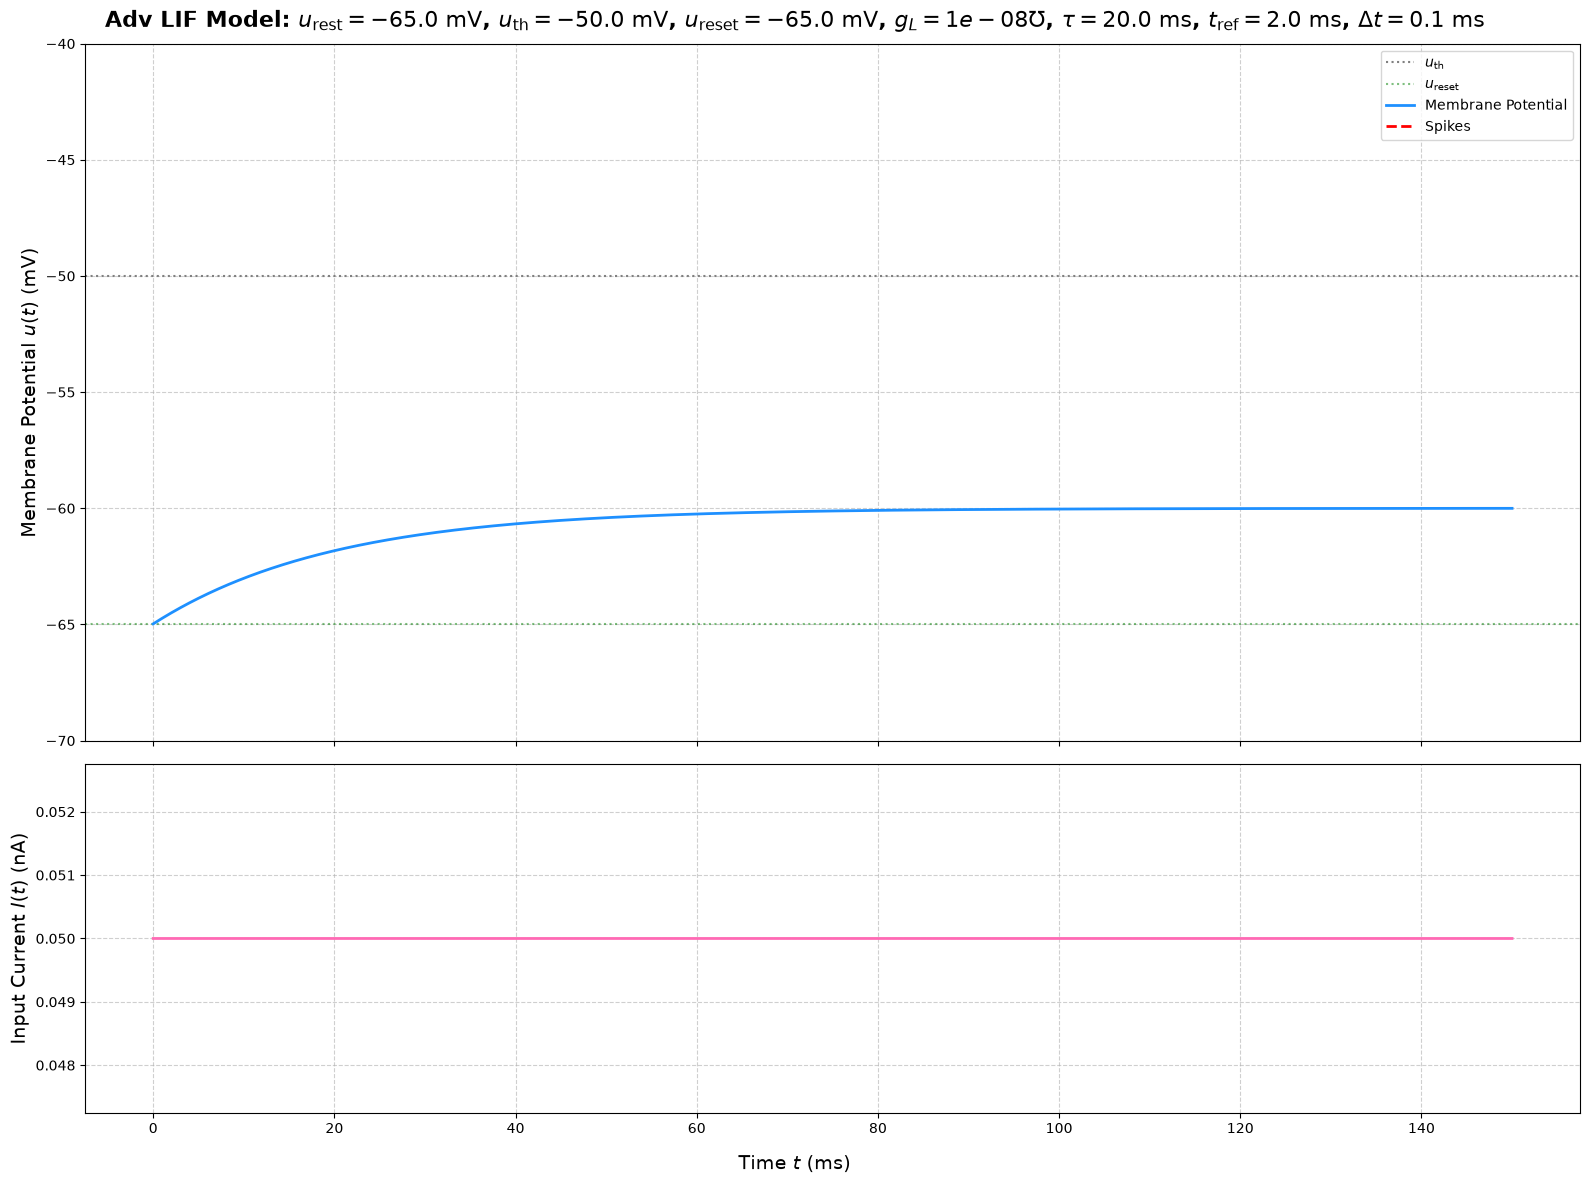

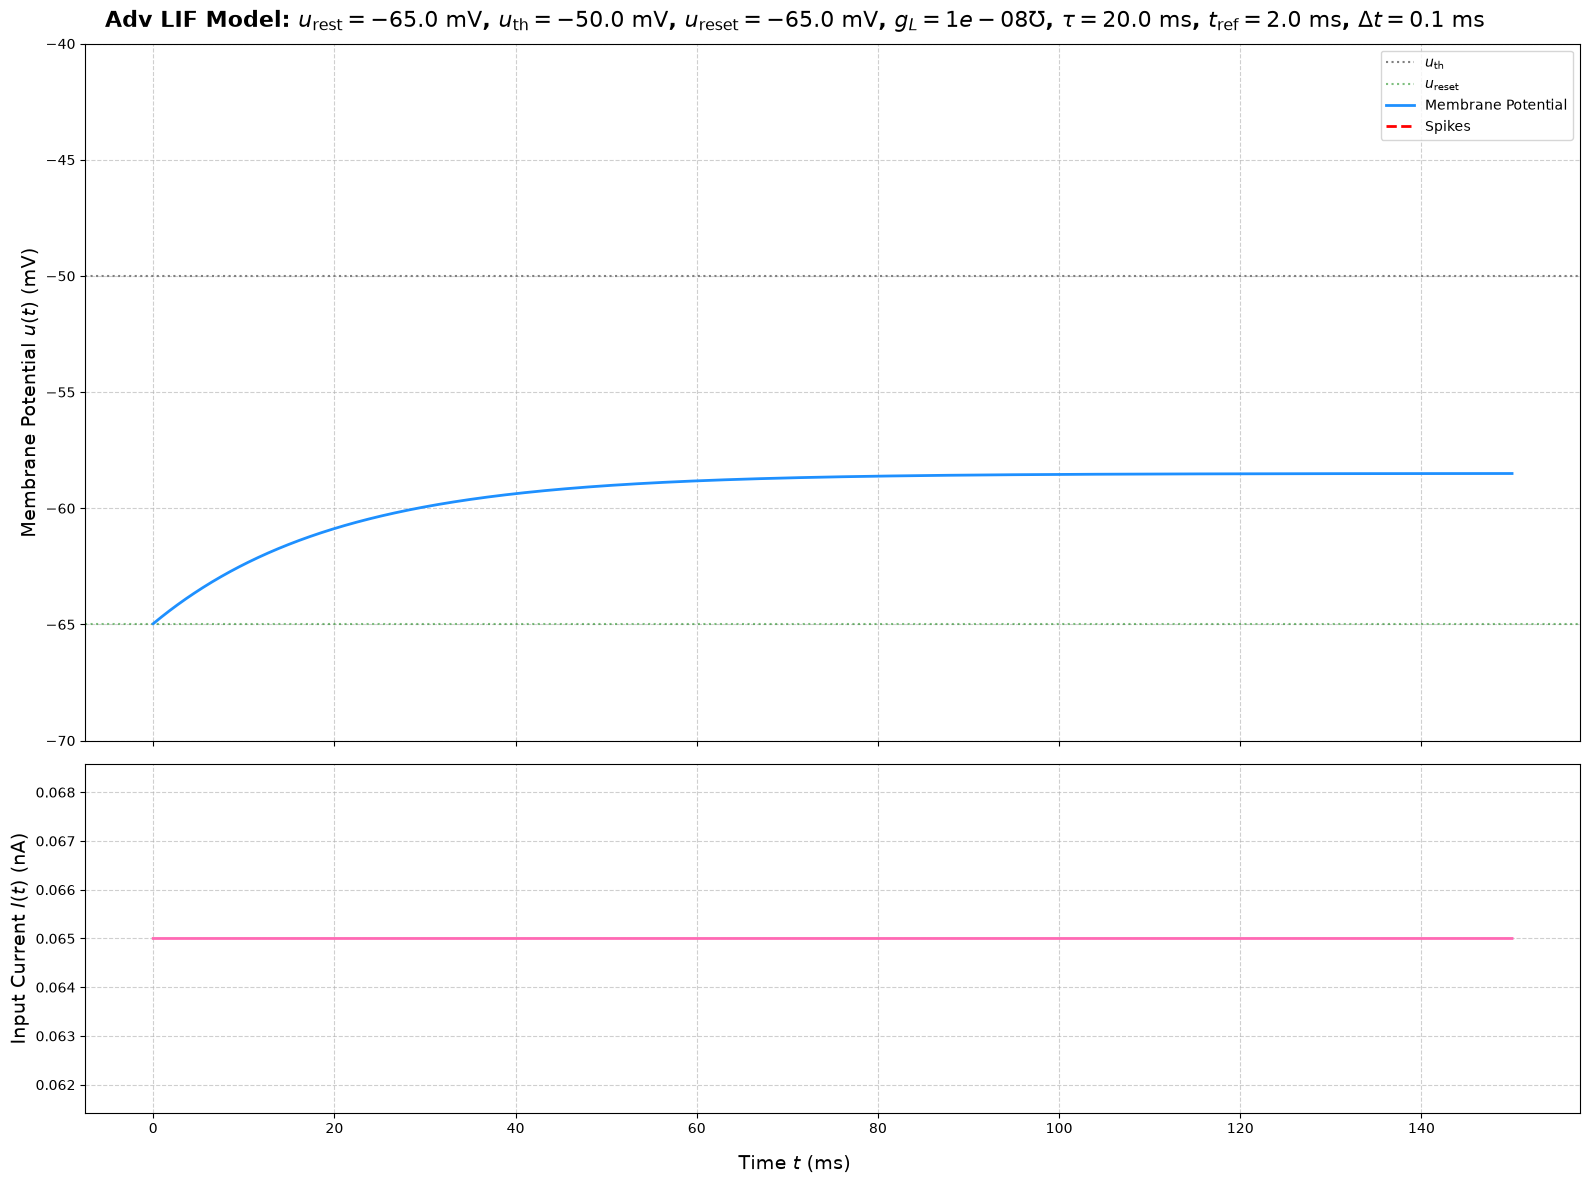

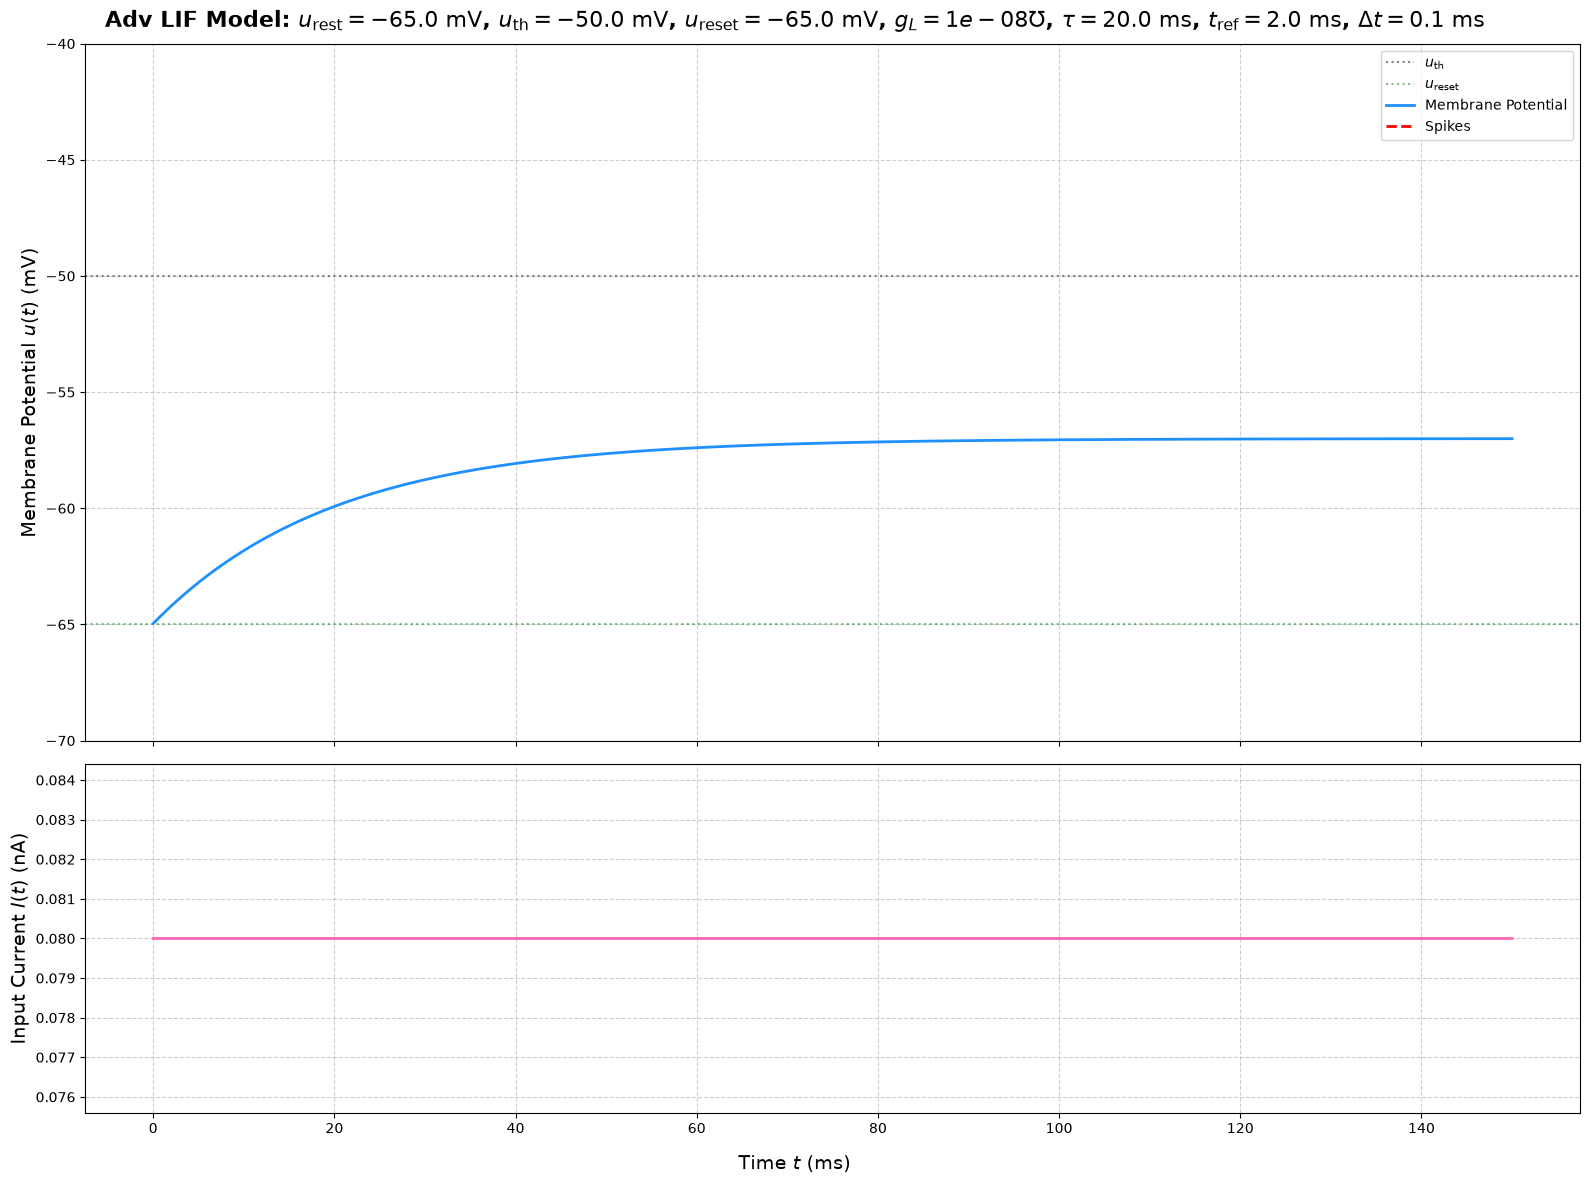

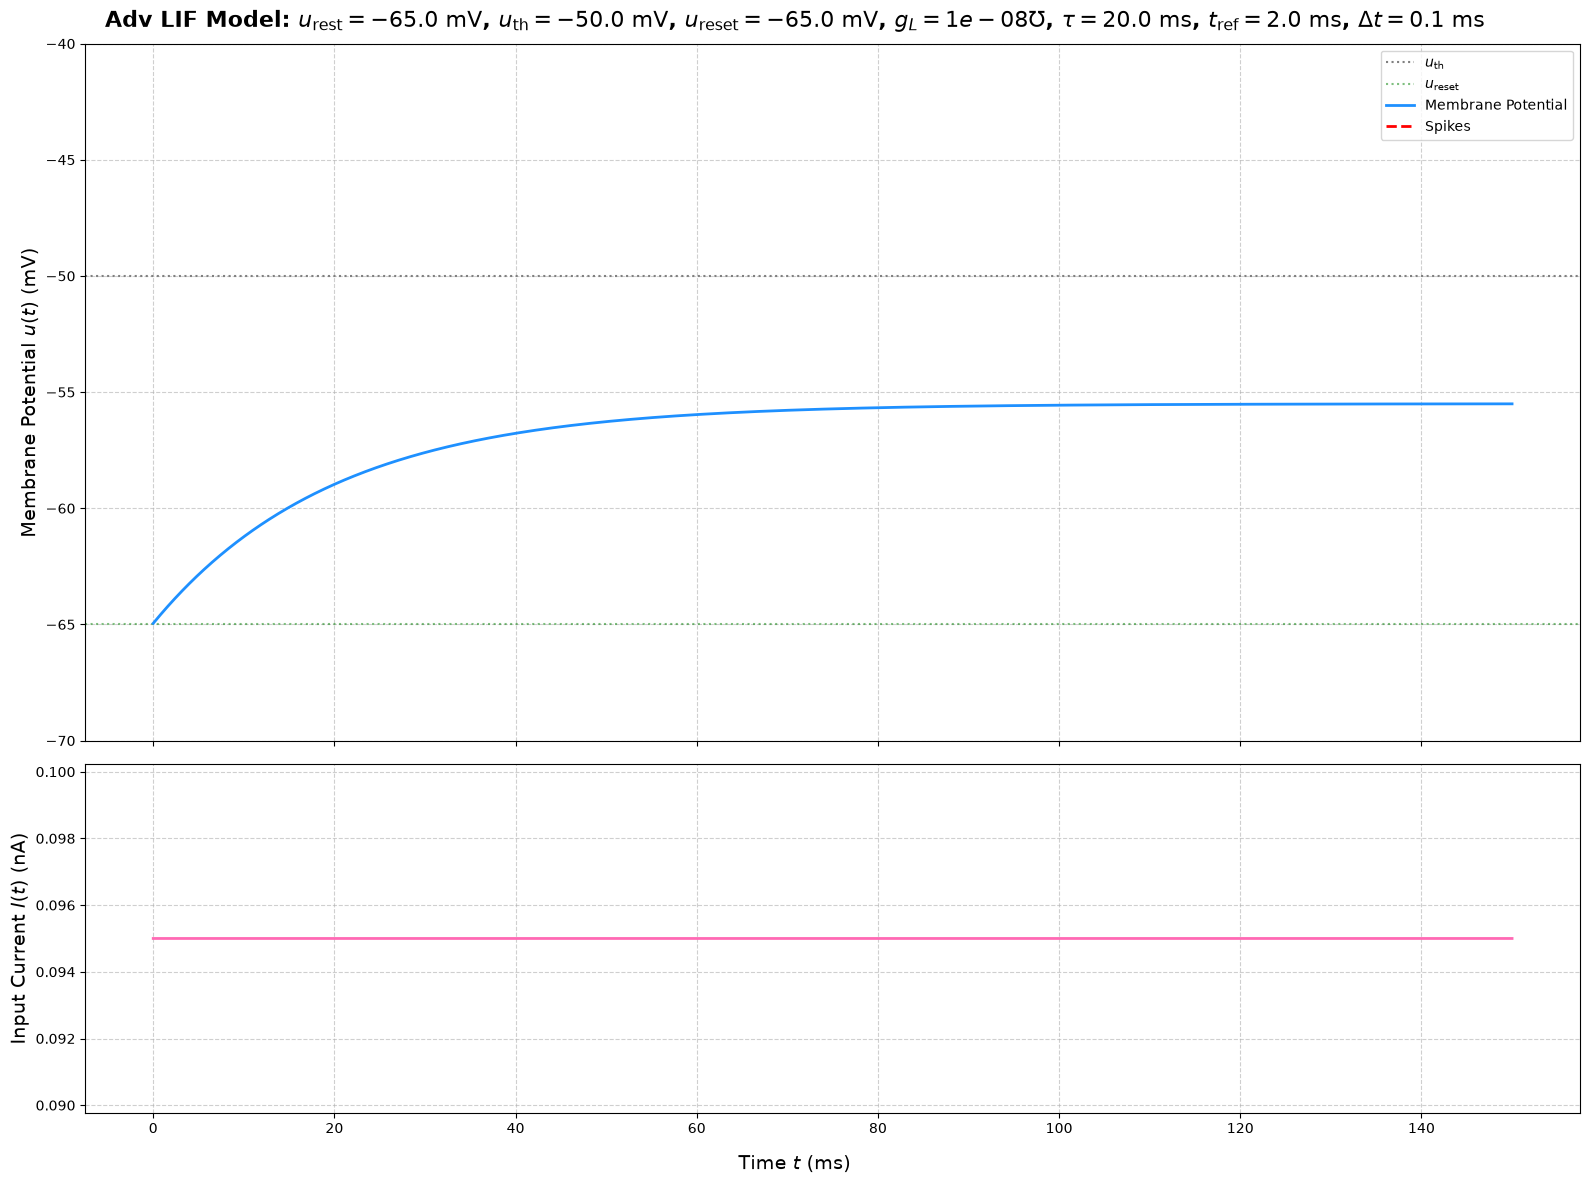

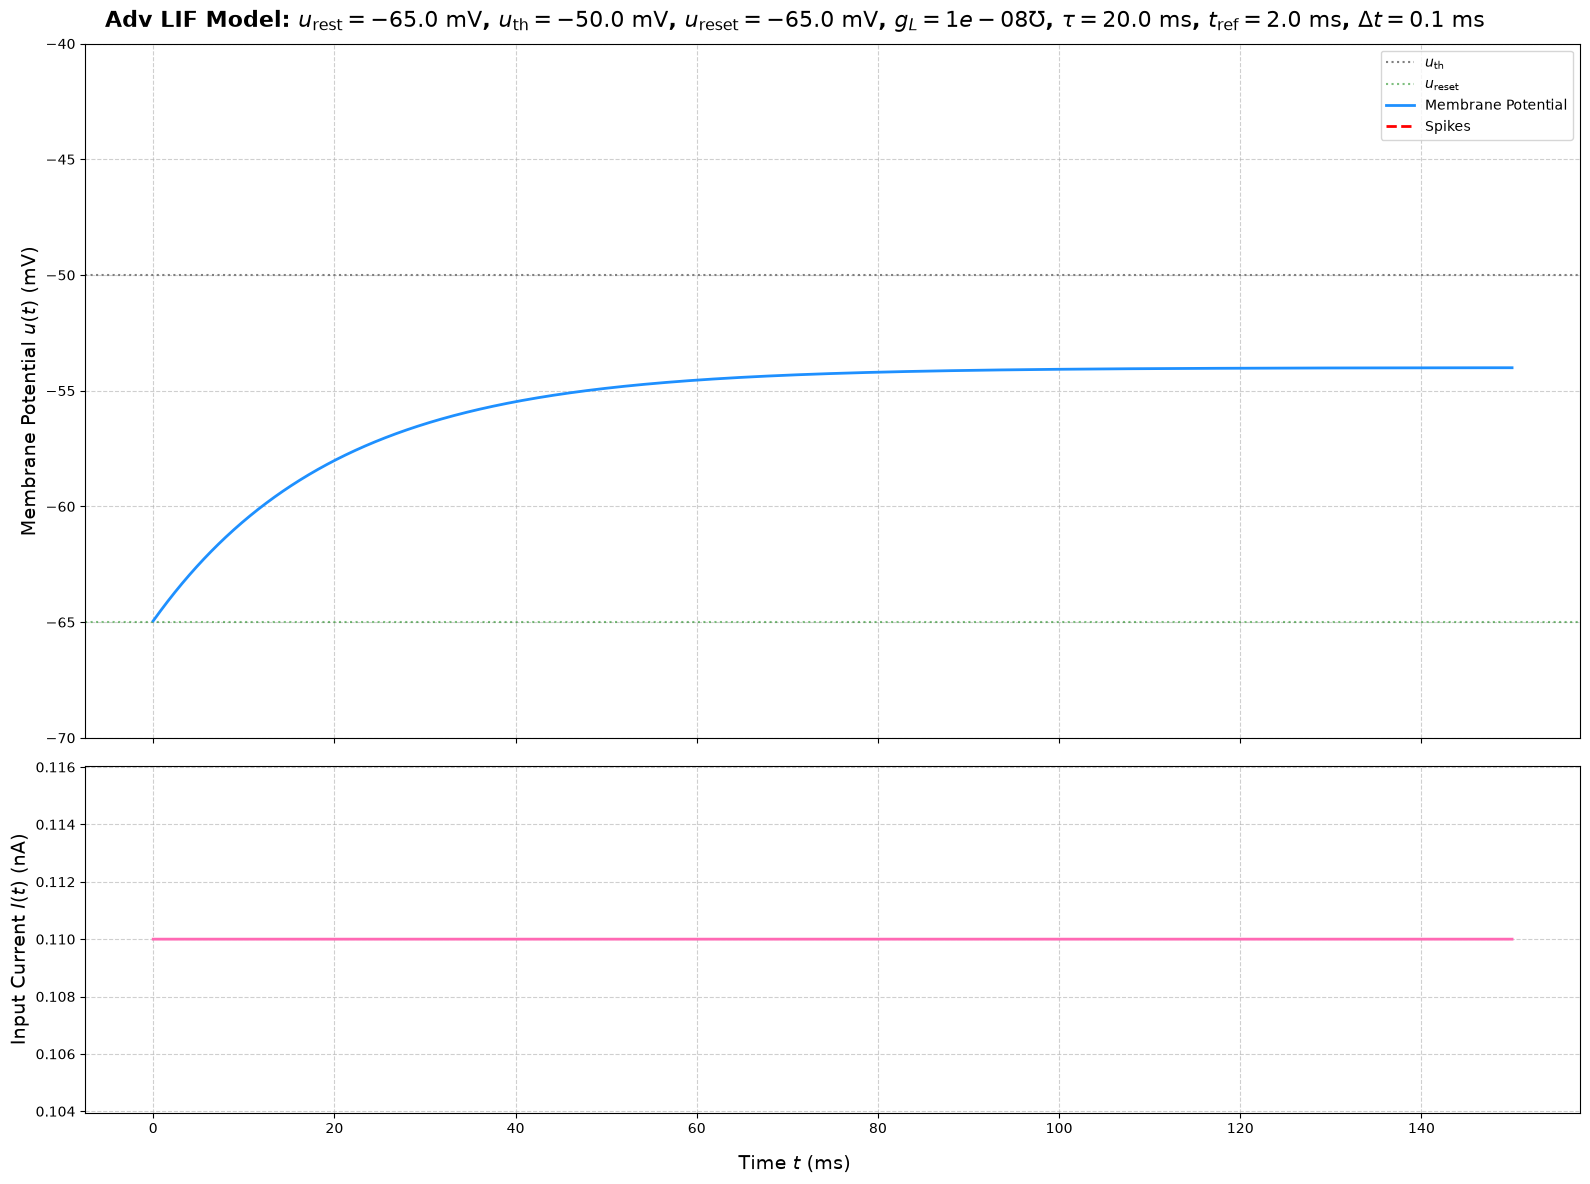

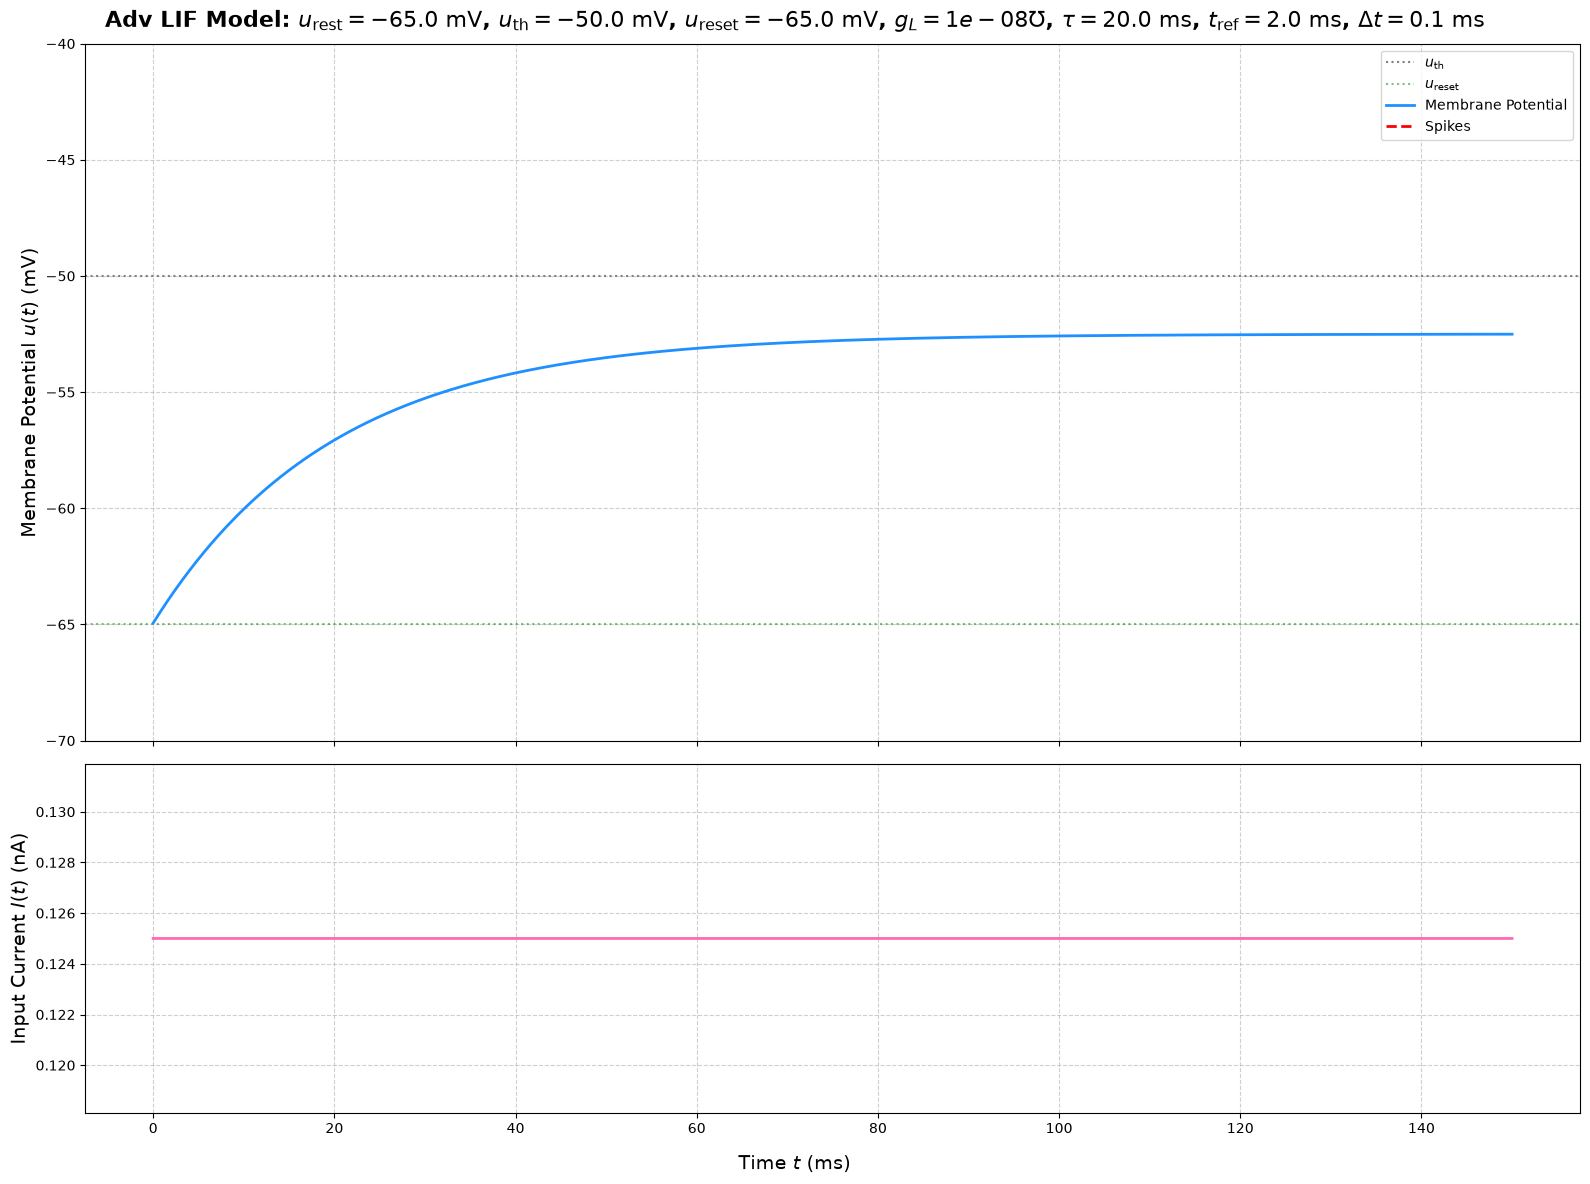

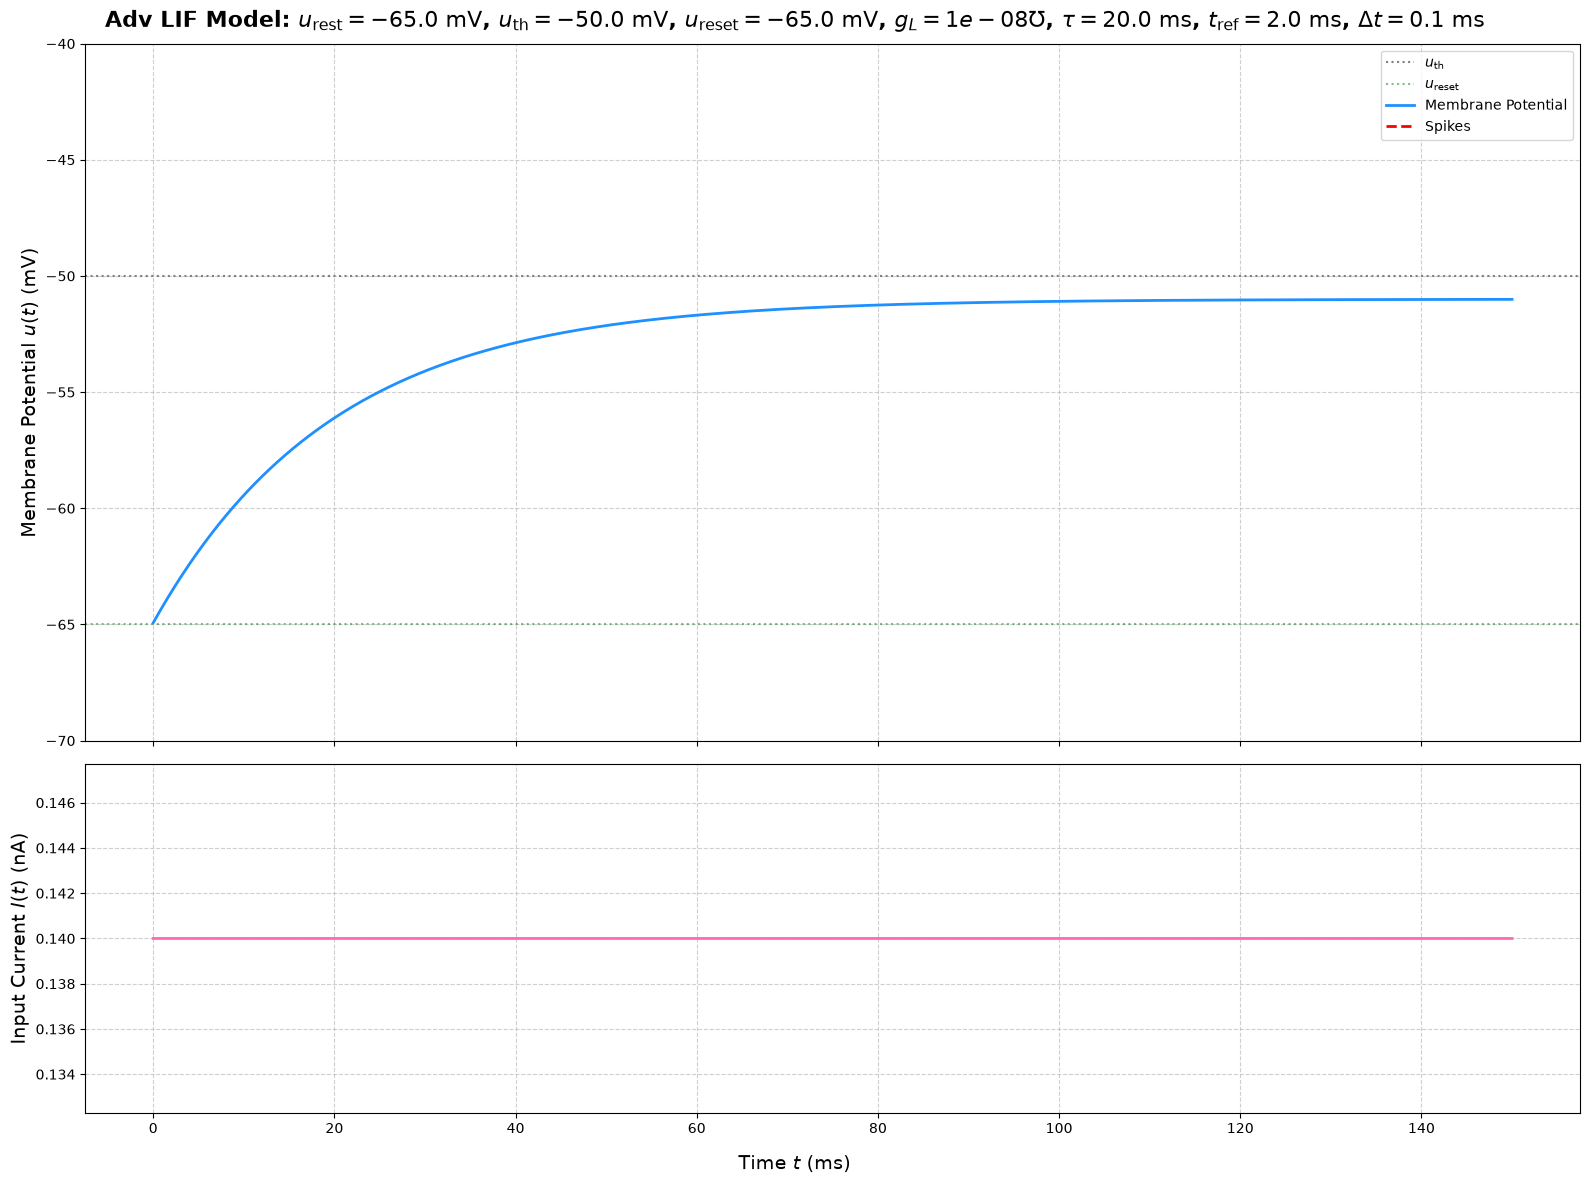

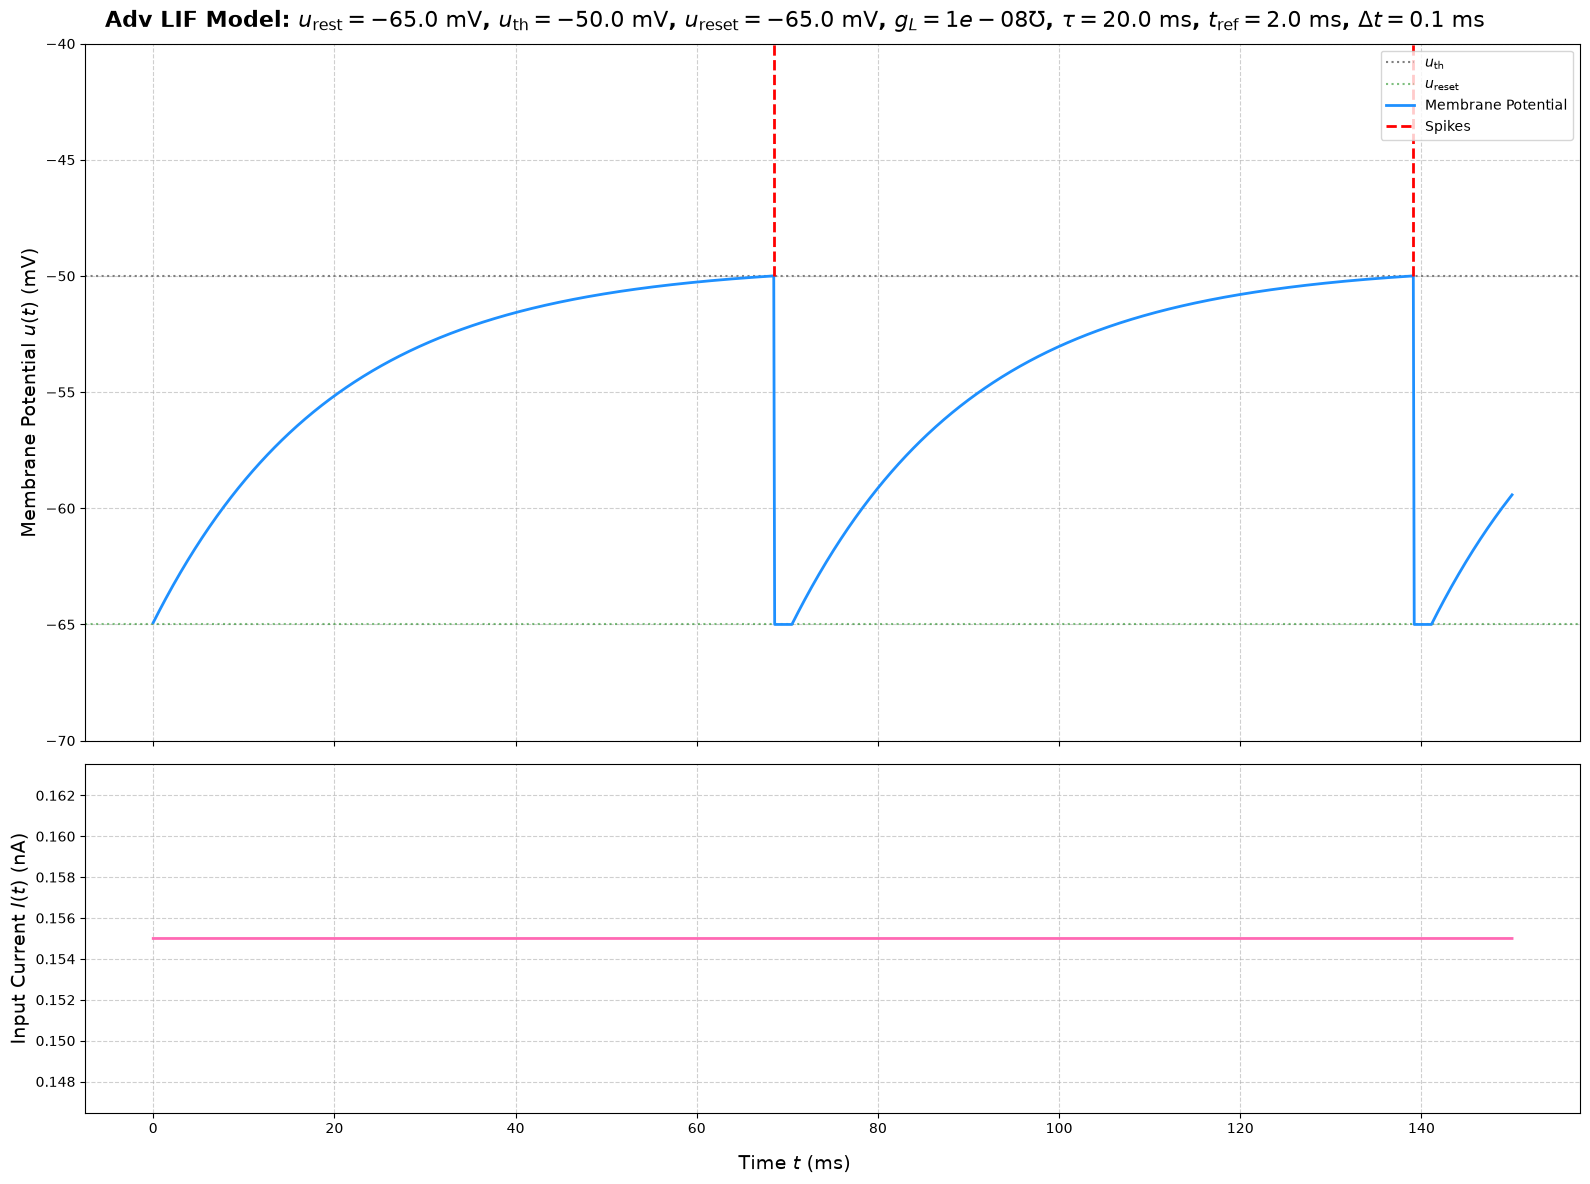

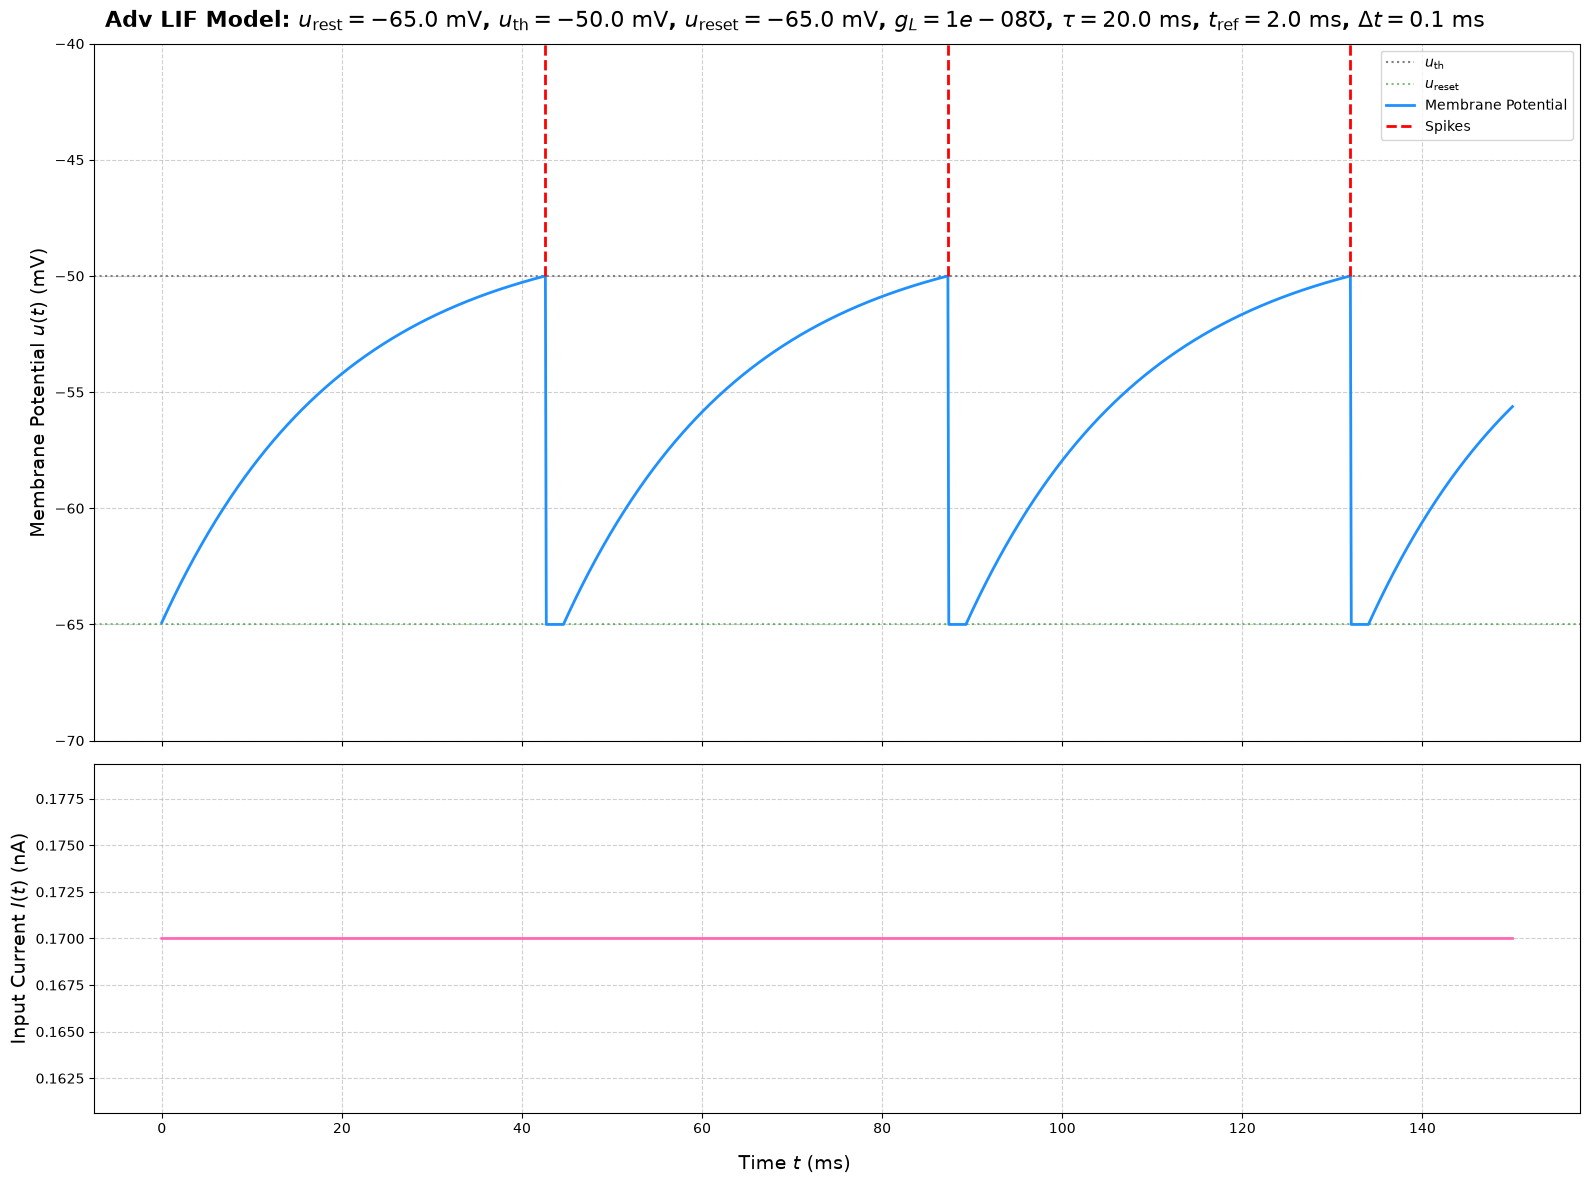

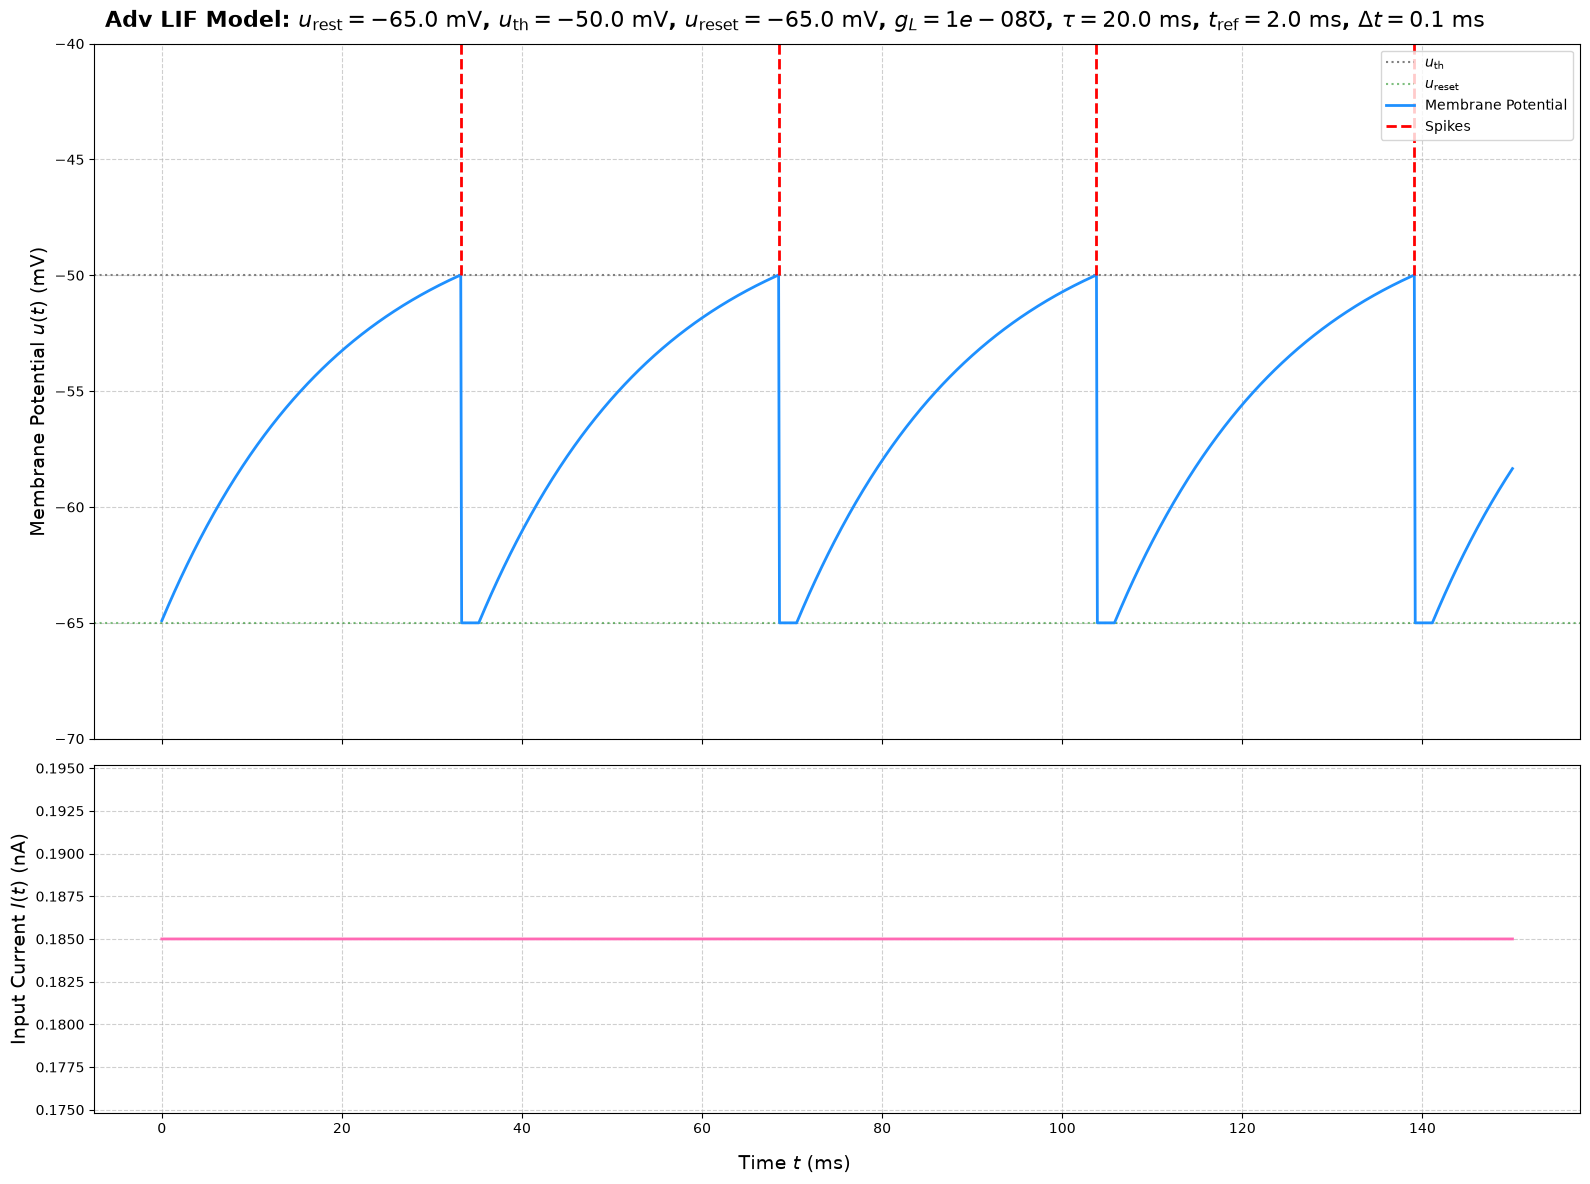

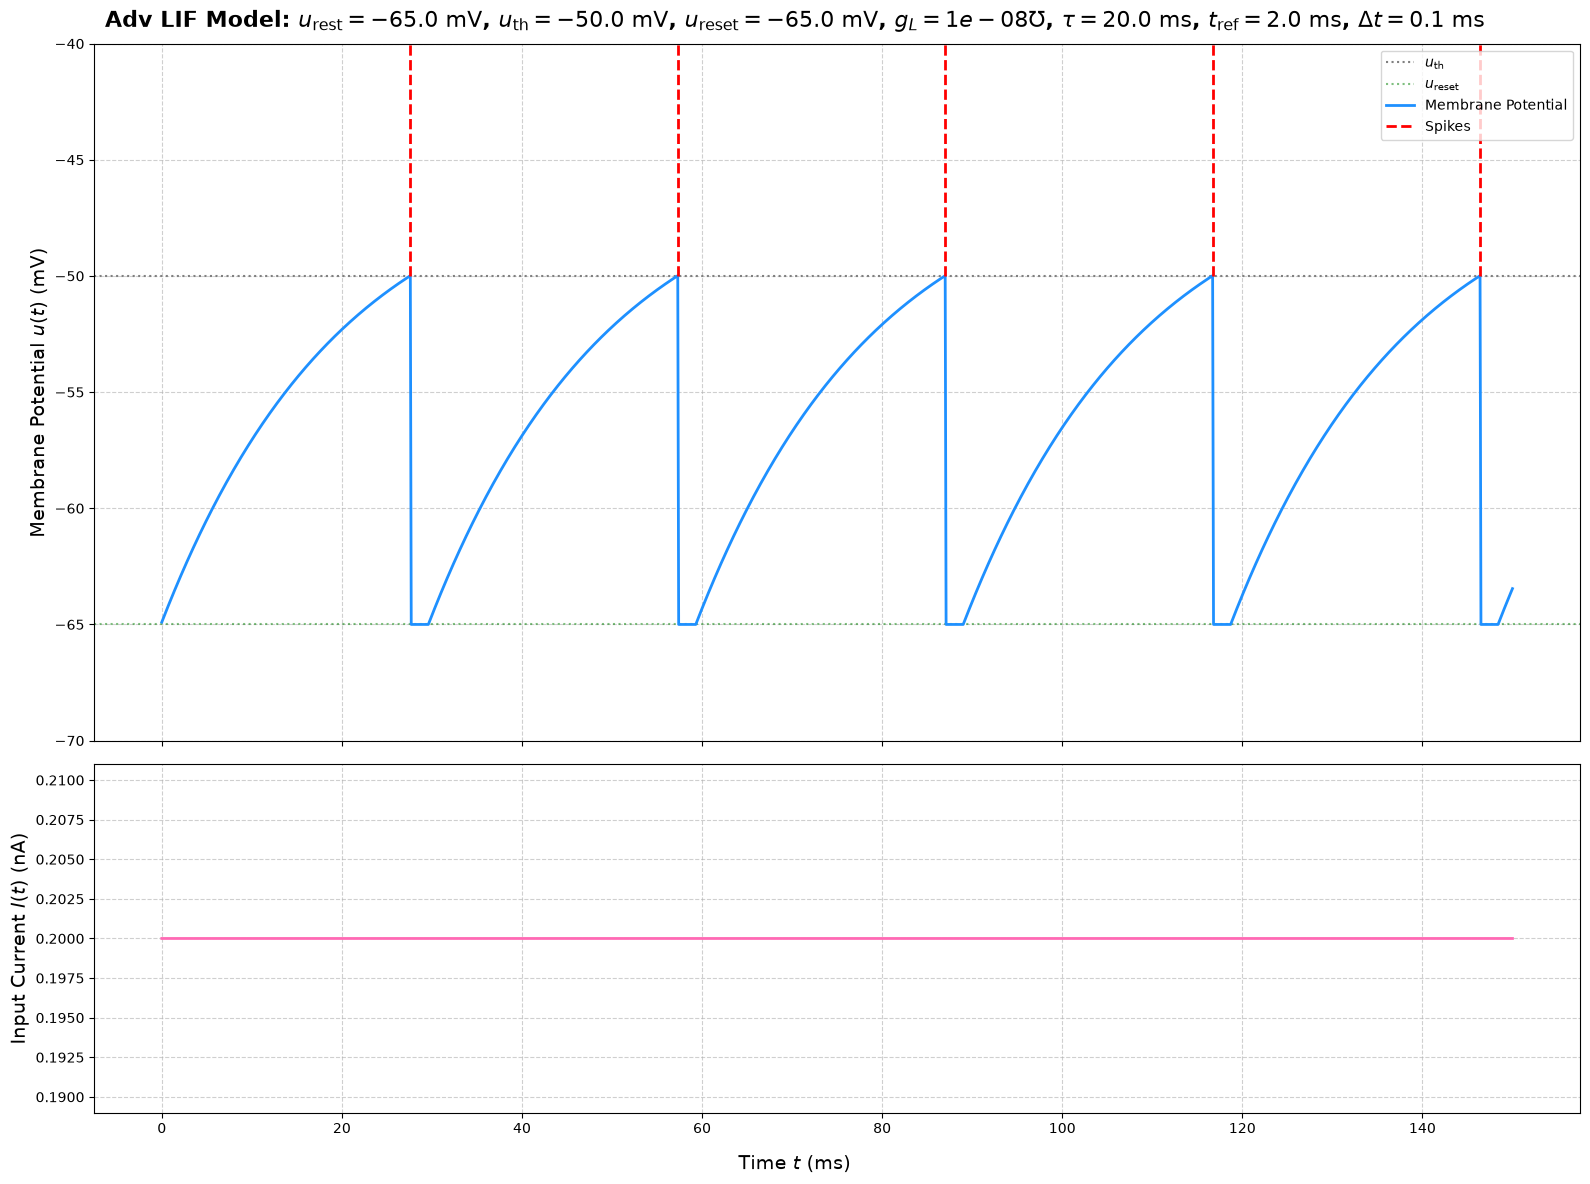

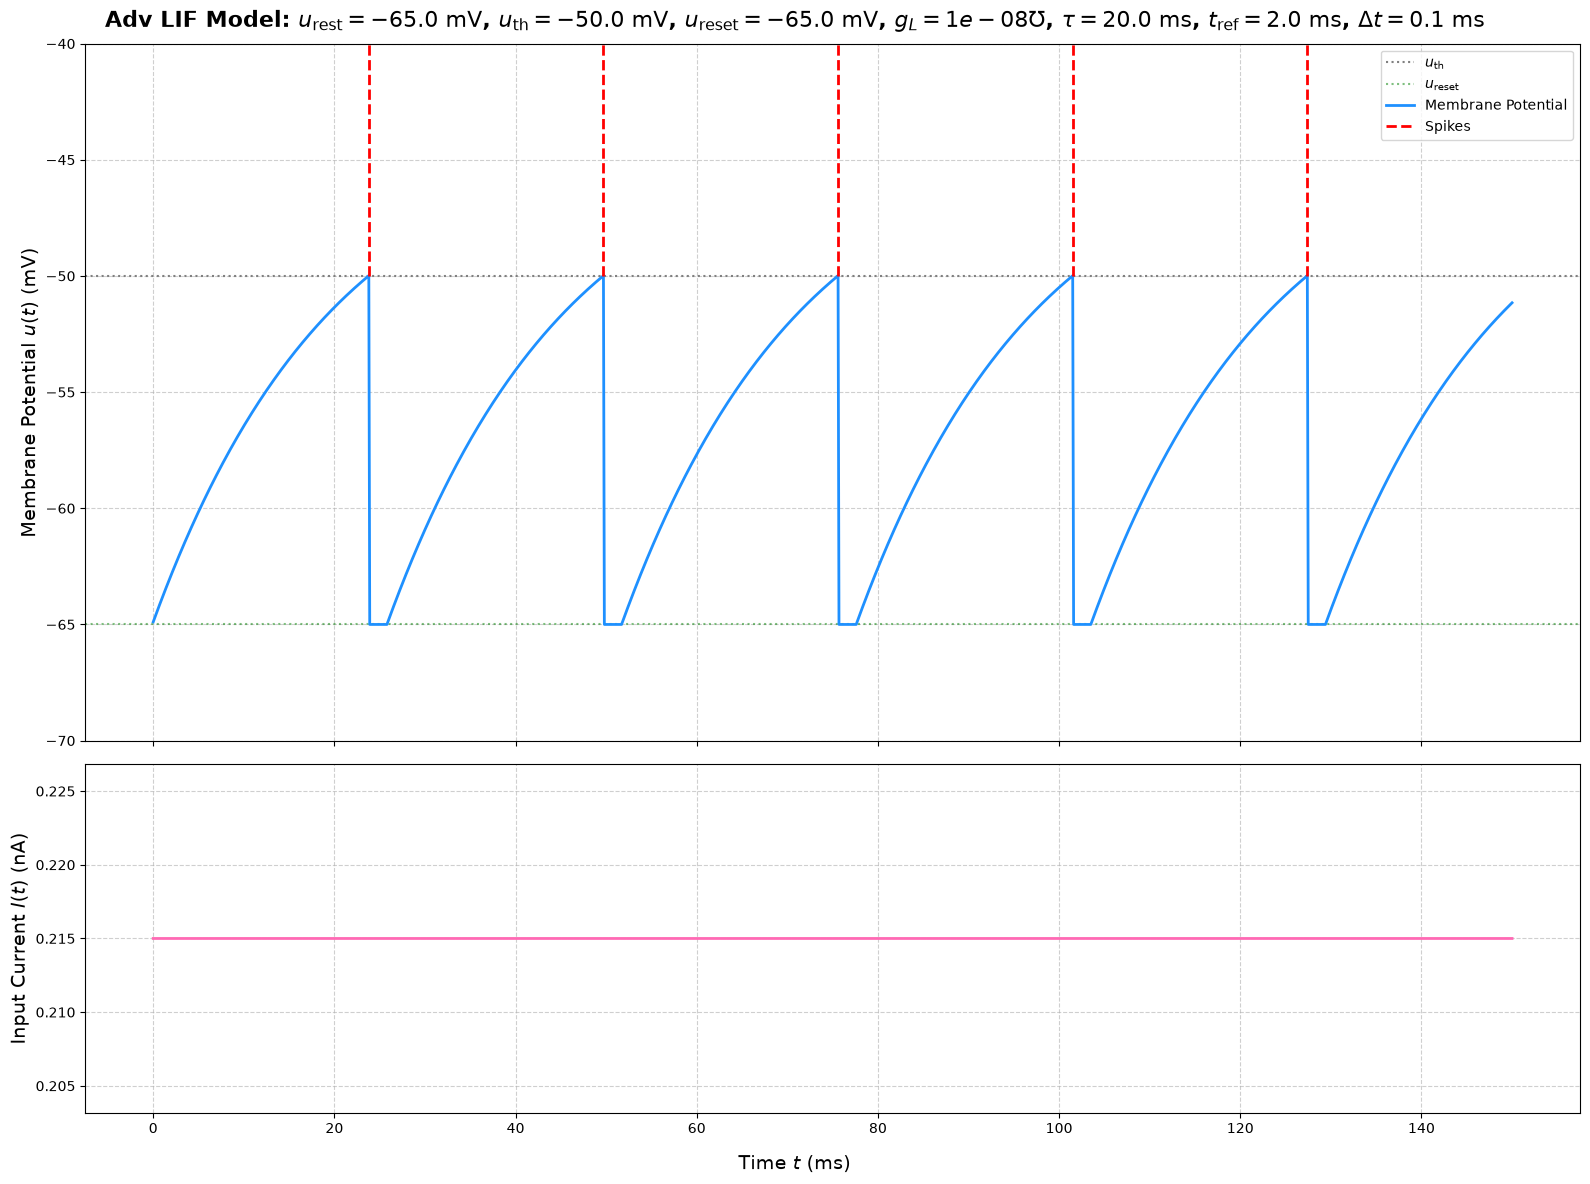

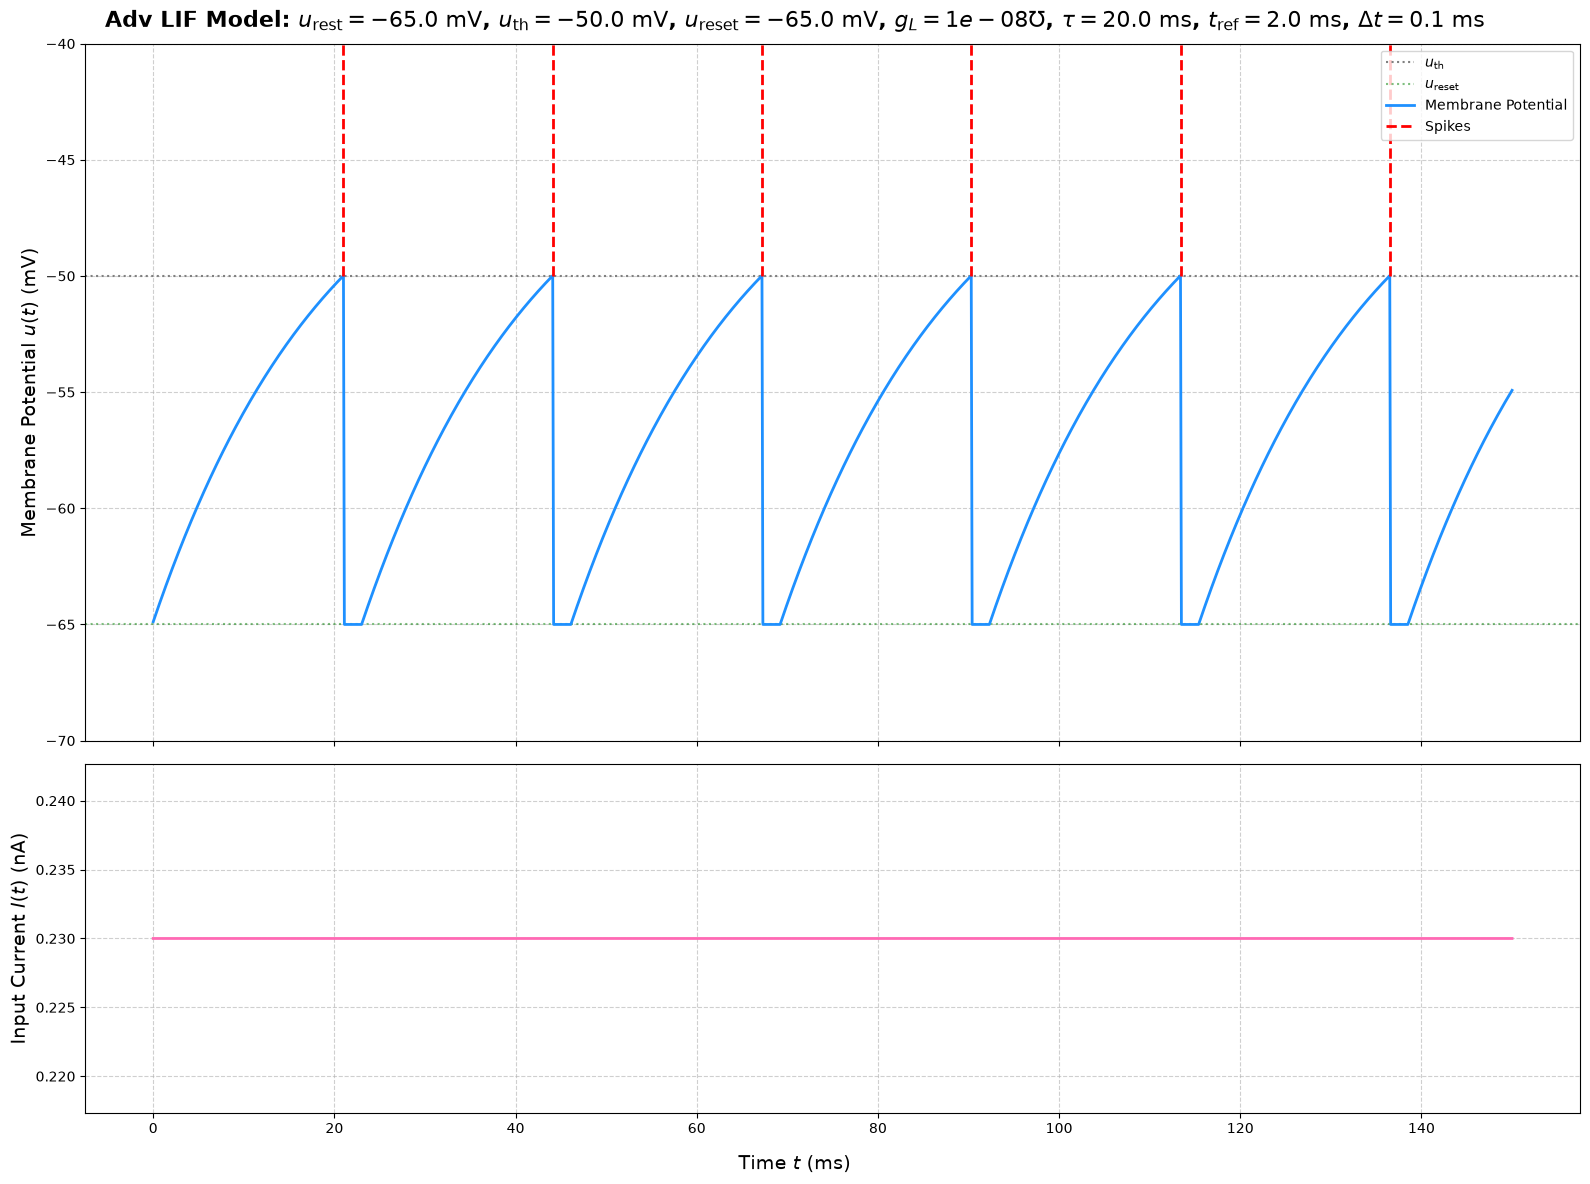

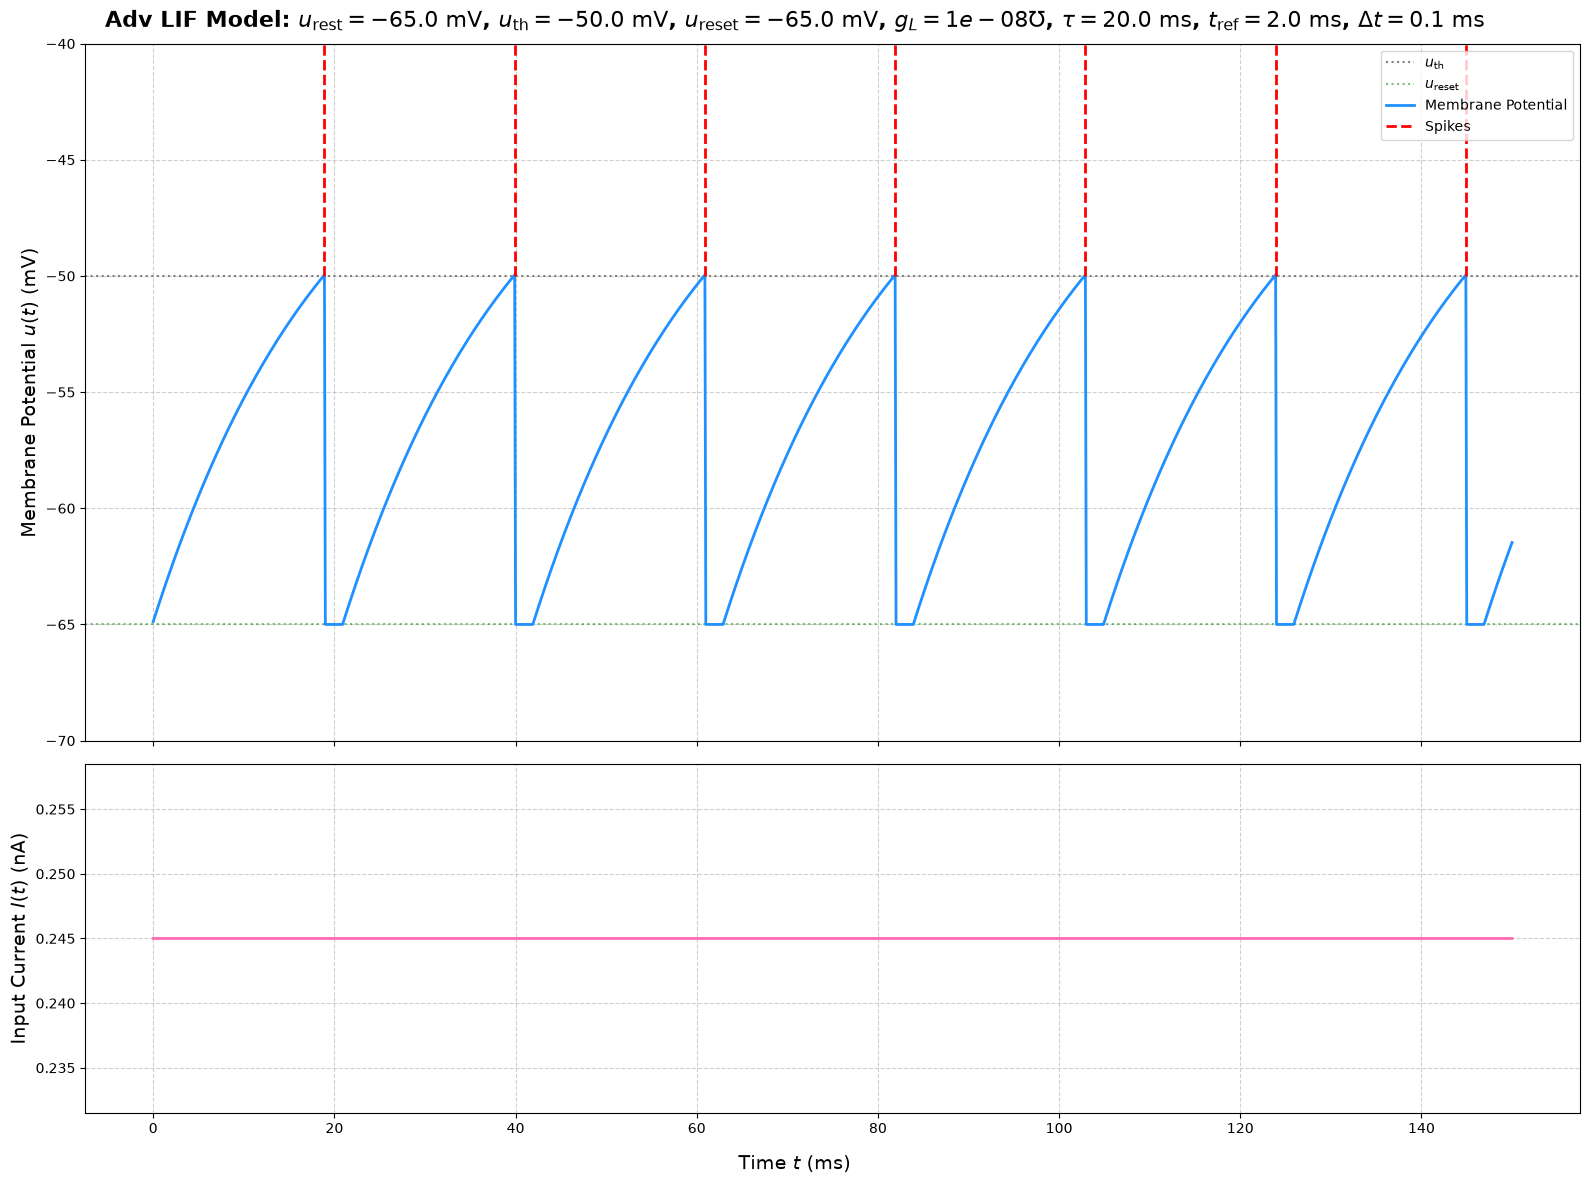

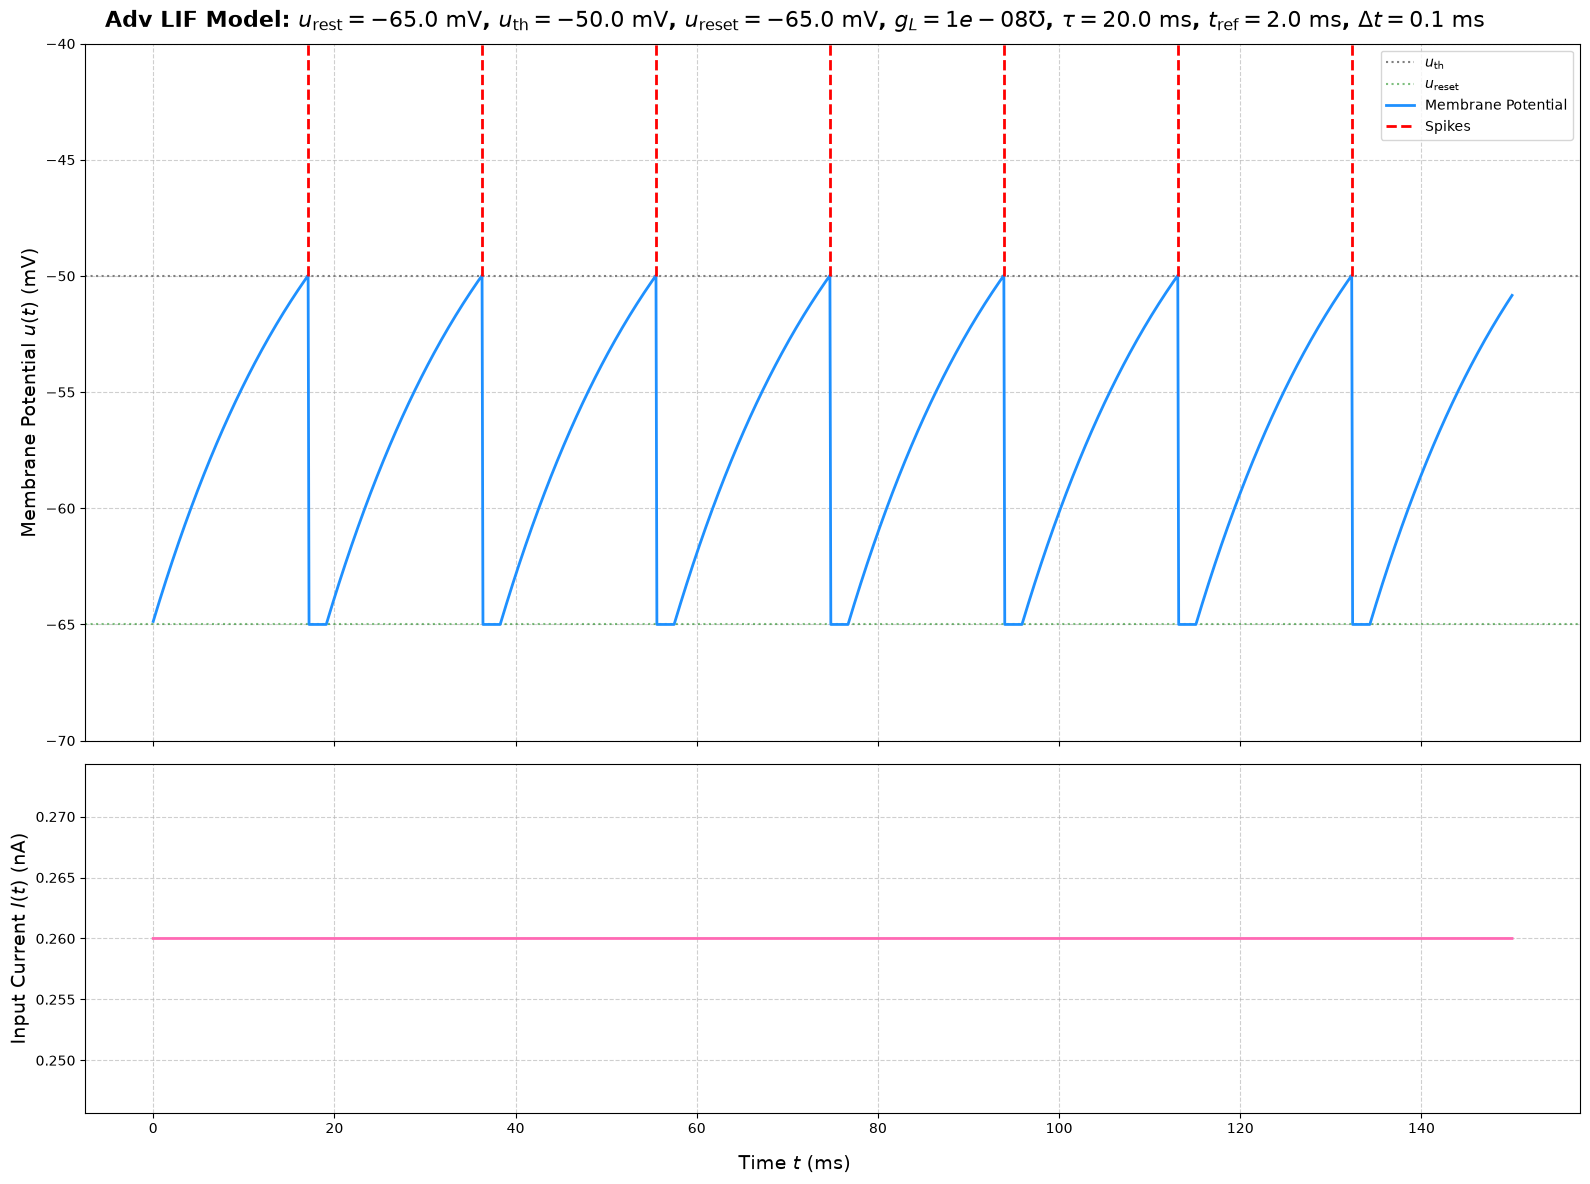

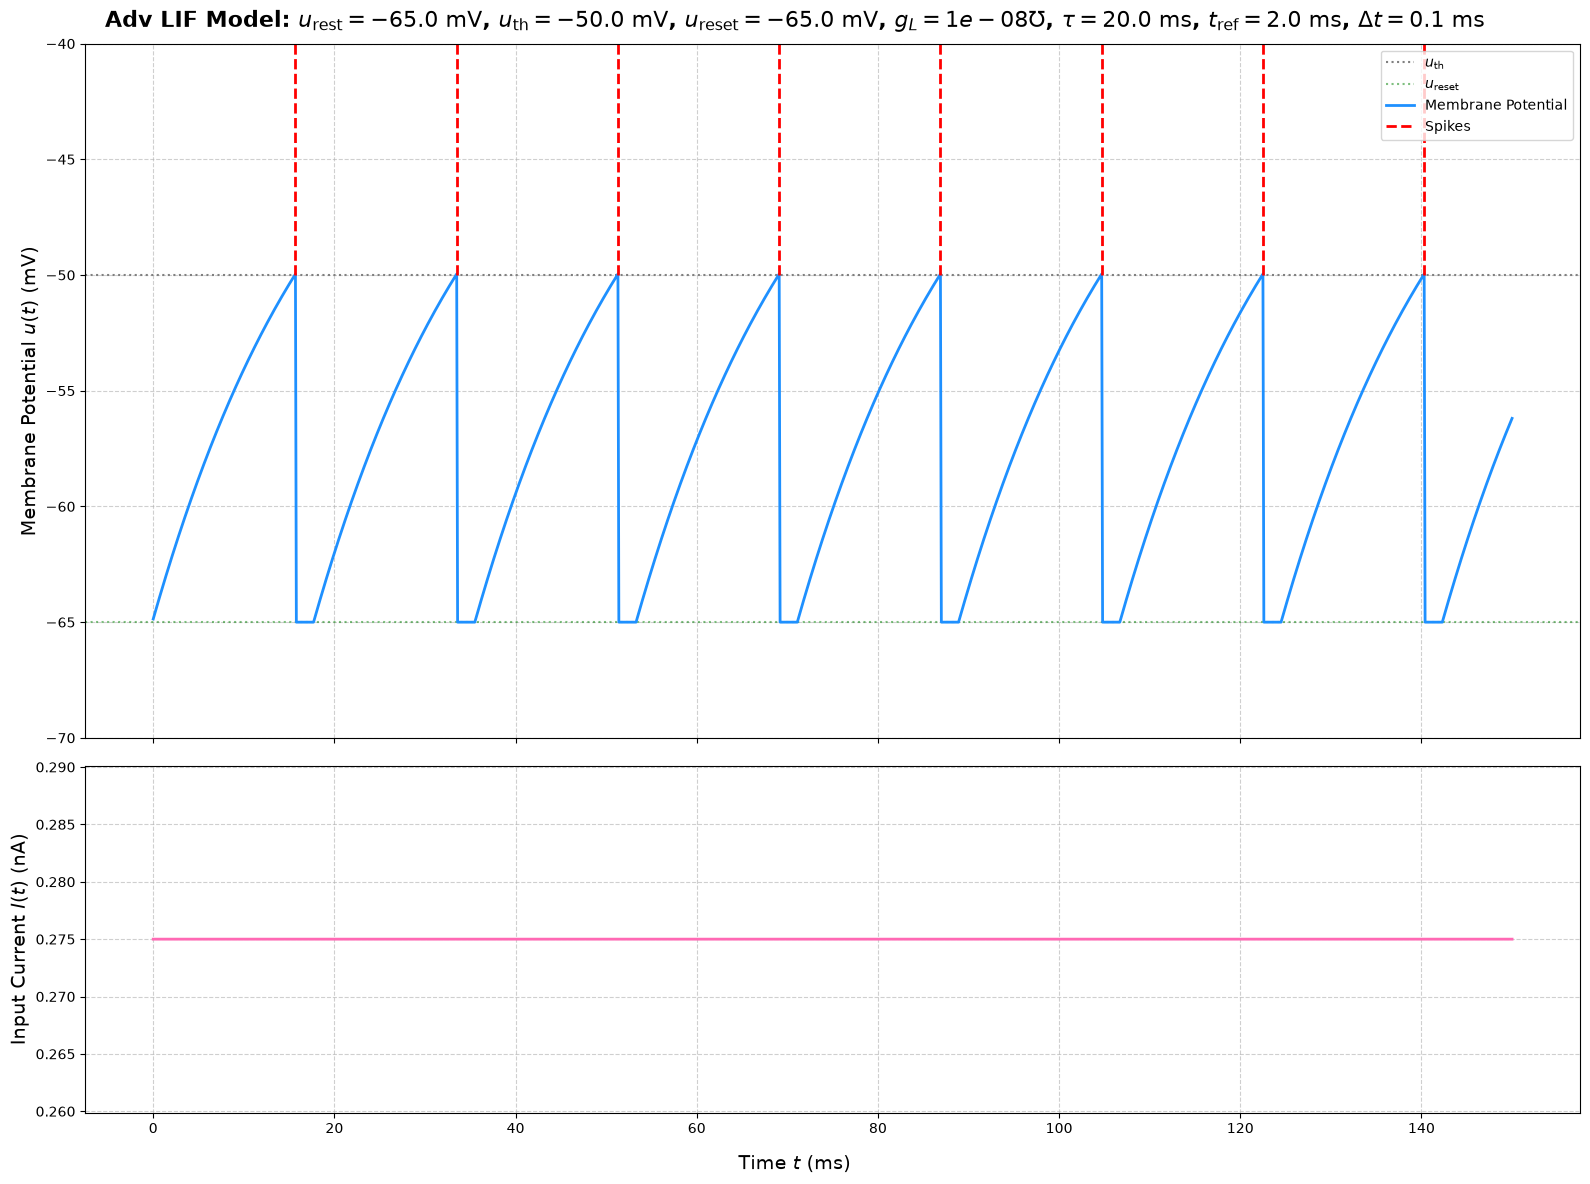

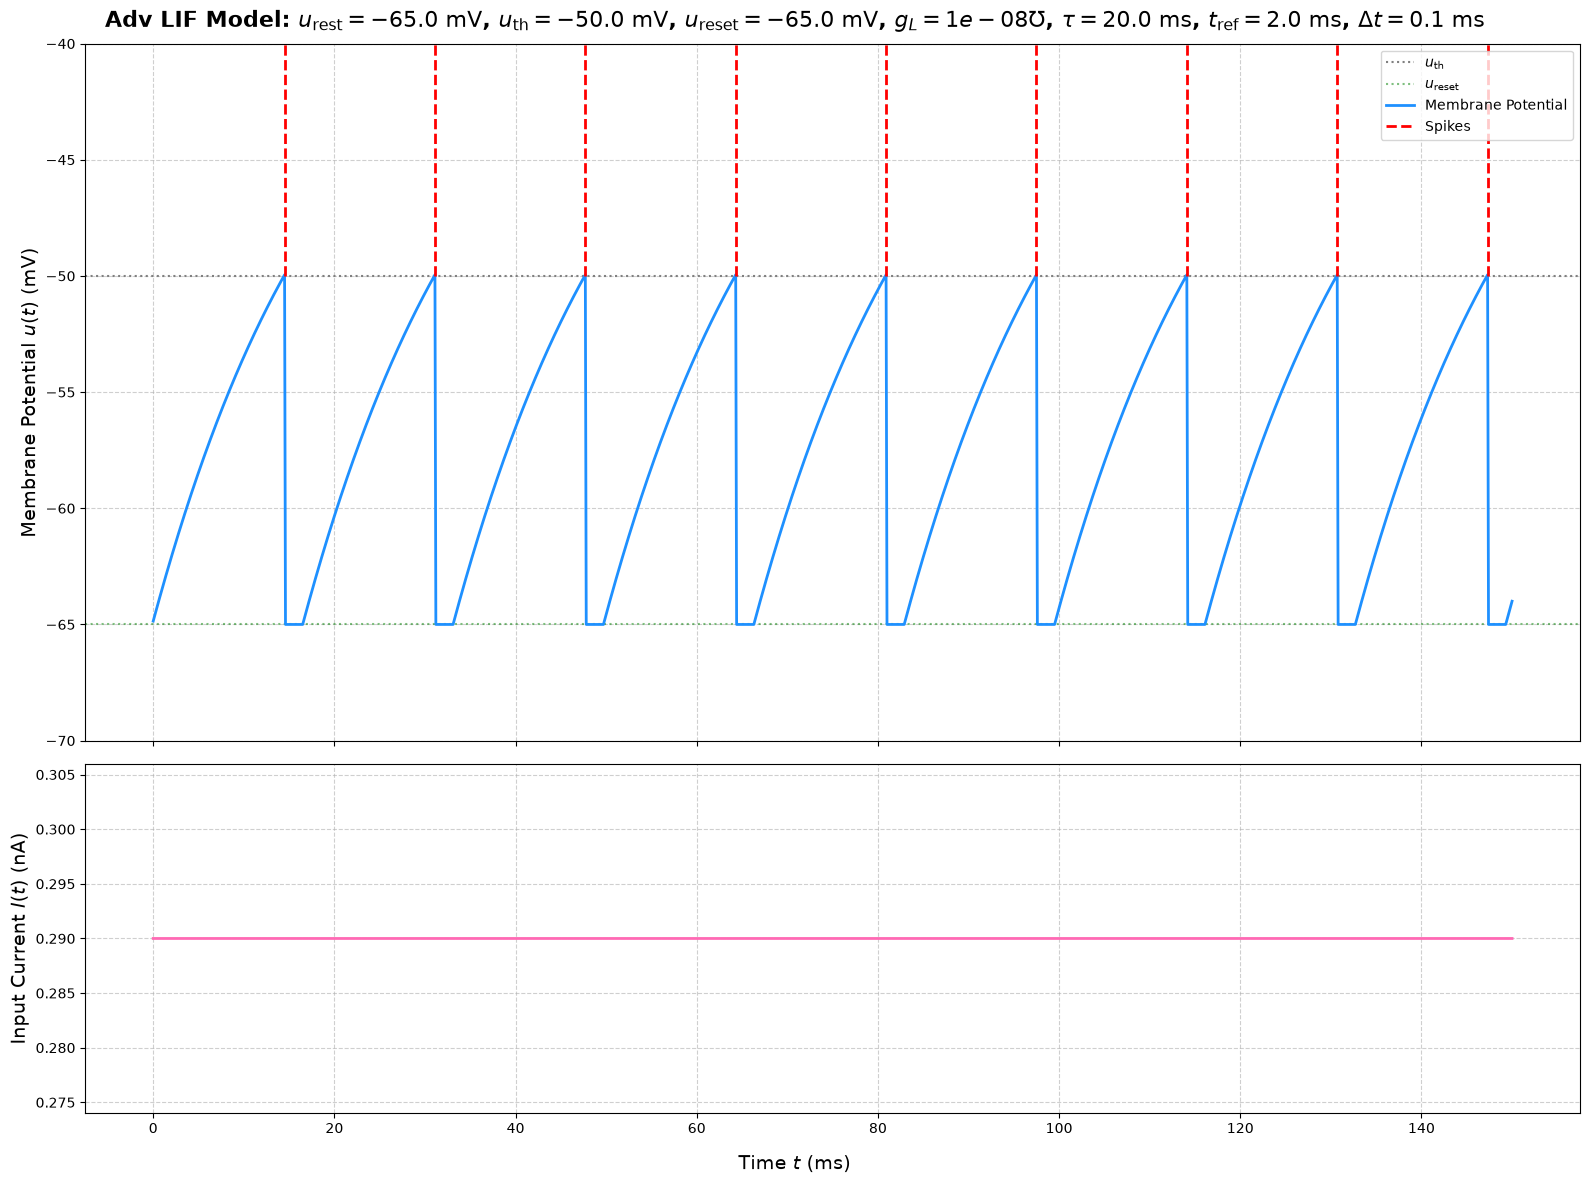

In [64]:
for I_0 in range(50, 300 + 1, 15):
    I_t = lambda t, I_0=I_0: I_0 * 1e-12
    U, I, T, spikes = simulate_adv_lif(
        u_rest, u_th, u_reset, gL, tau, I_t, t_ref, delta_t, t_0=0, t_1=0.15
    )
    plot_membrane_potential(U, I, T, spikes, f"./q3_2/plots/i_{I_0}.png")
    np.savetxt(f"./q3_2/traces/i_{I_0}.txt", U)

In [59]:
print(rf"Theoretical Rheobase Current I_rh = {(gL * (u_th - u_rest)) * 1e12} pA")

Theoretical Rheobase Current I_rh = 150.0 pA


## 3 : Effect of the Membrane Time Constant

In [116]:
I_t = lambda t: 200 * 1e-12

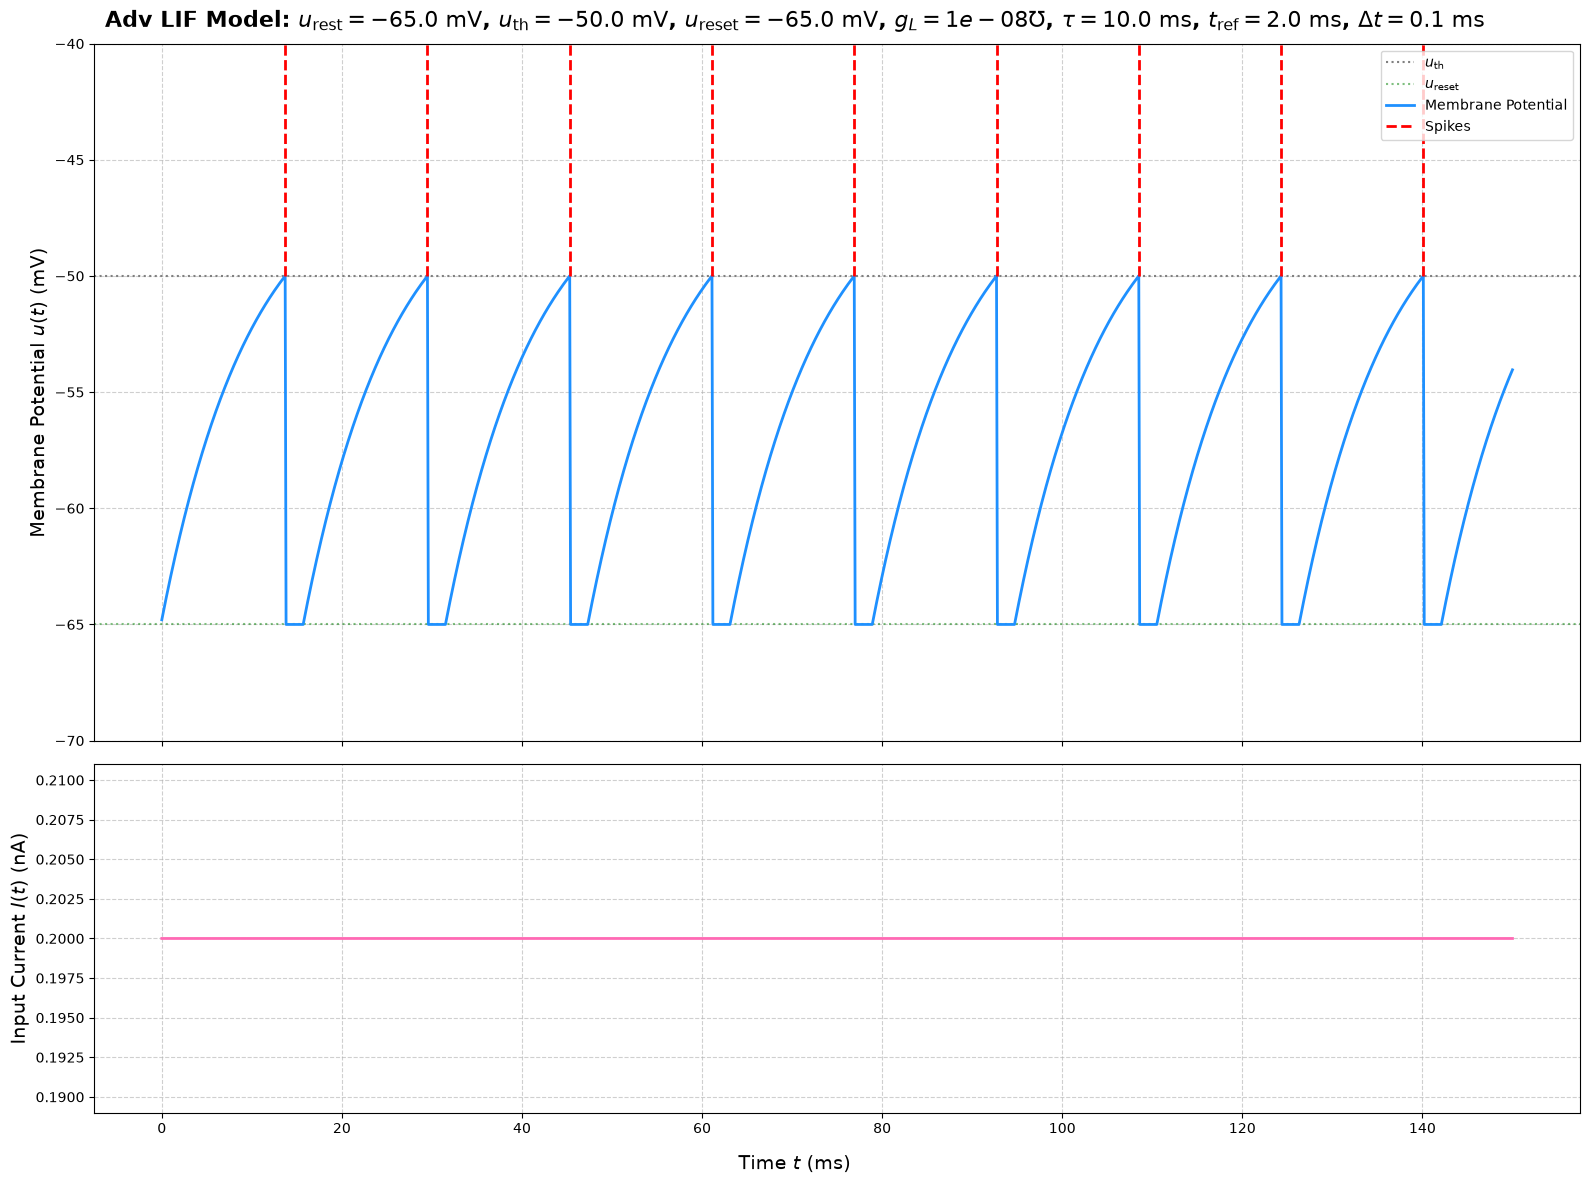

Inter Spike Time for tau=0.01 is 0.015800000000000113
Firing rate for tau=0.01 is 63.29113924050588


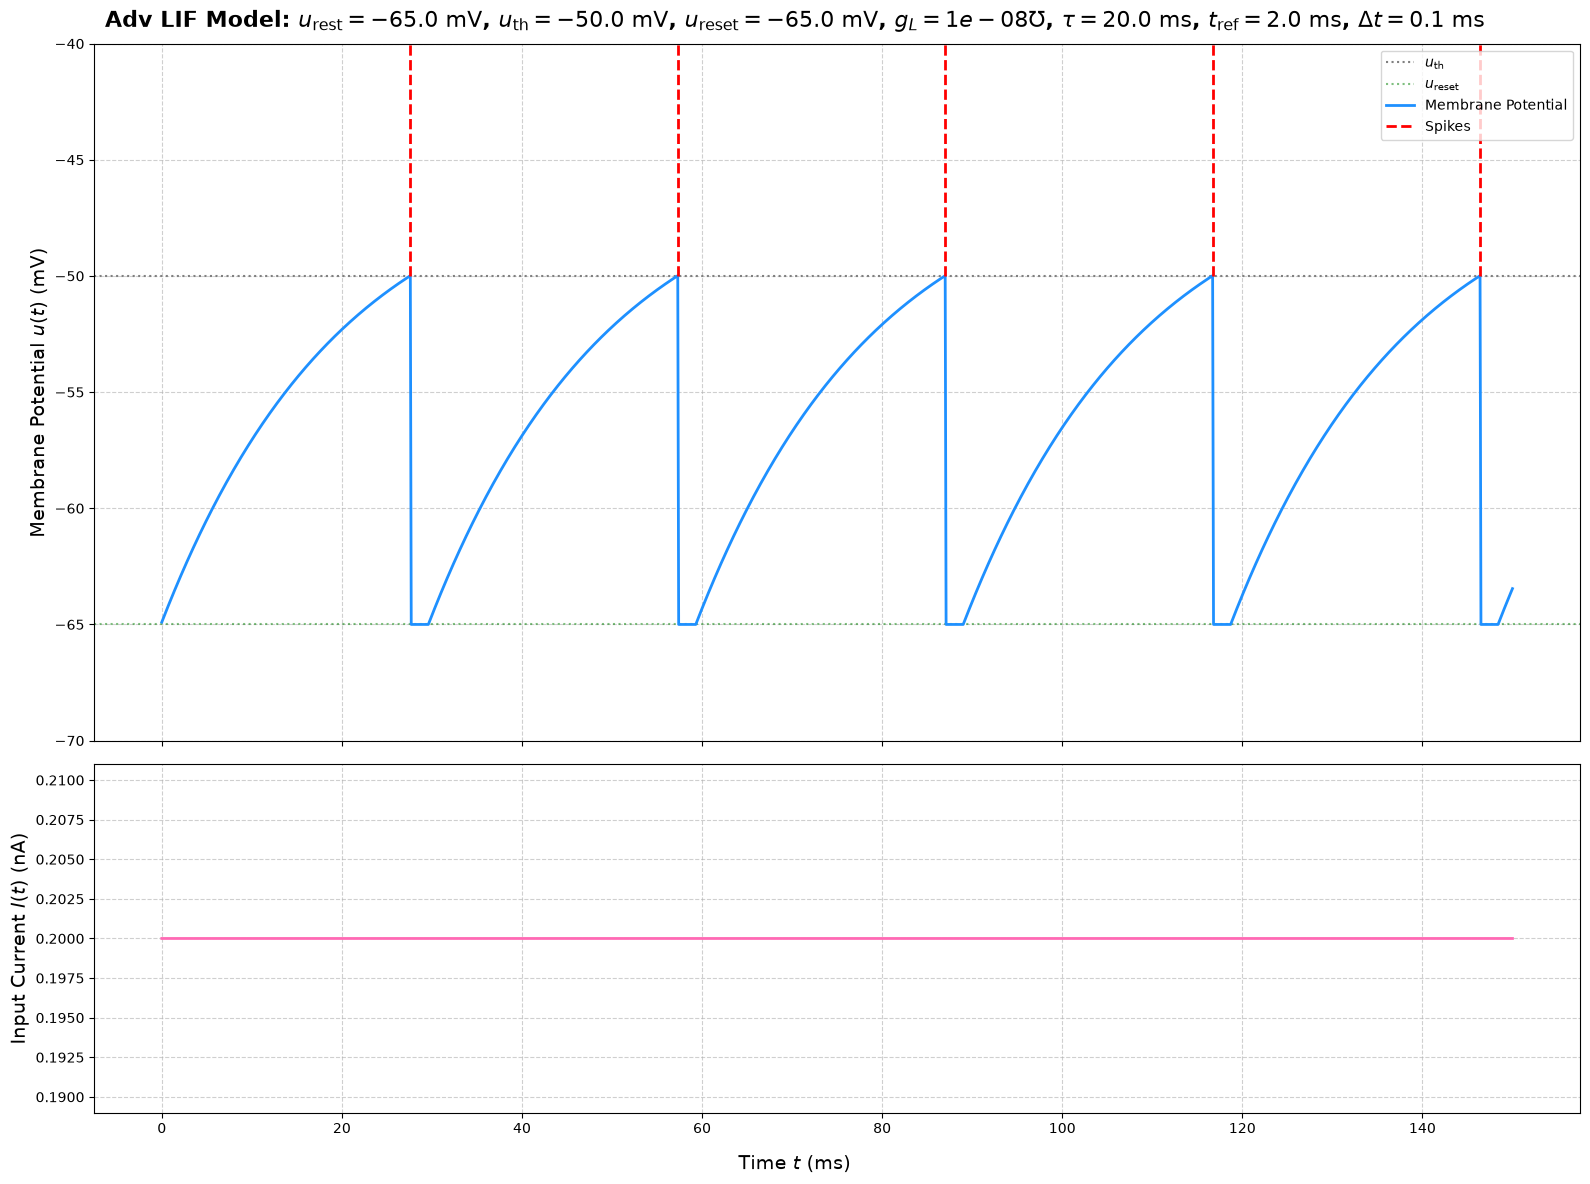

Inter Spike Time for tau=0.02 is 0.029700000000000077
Firing rate for tau=0.02 is 33.67003367003358


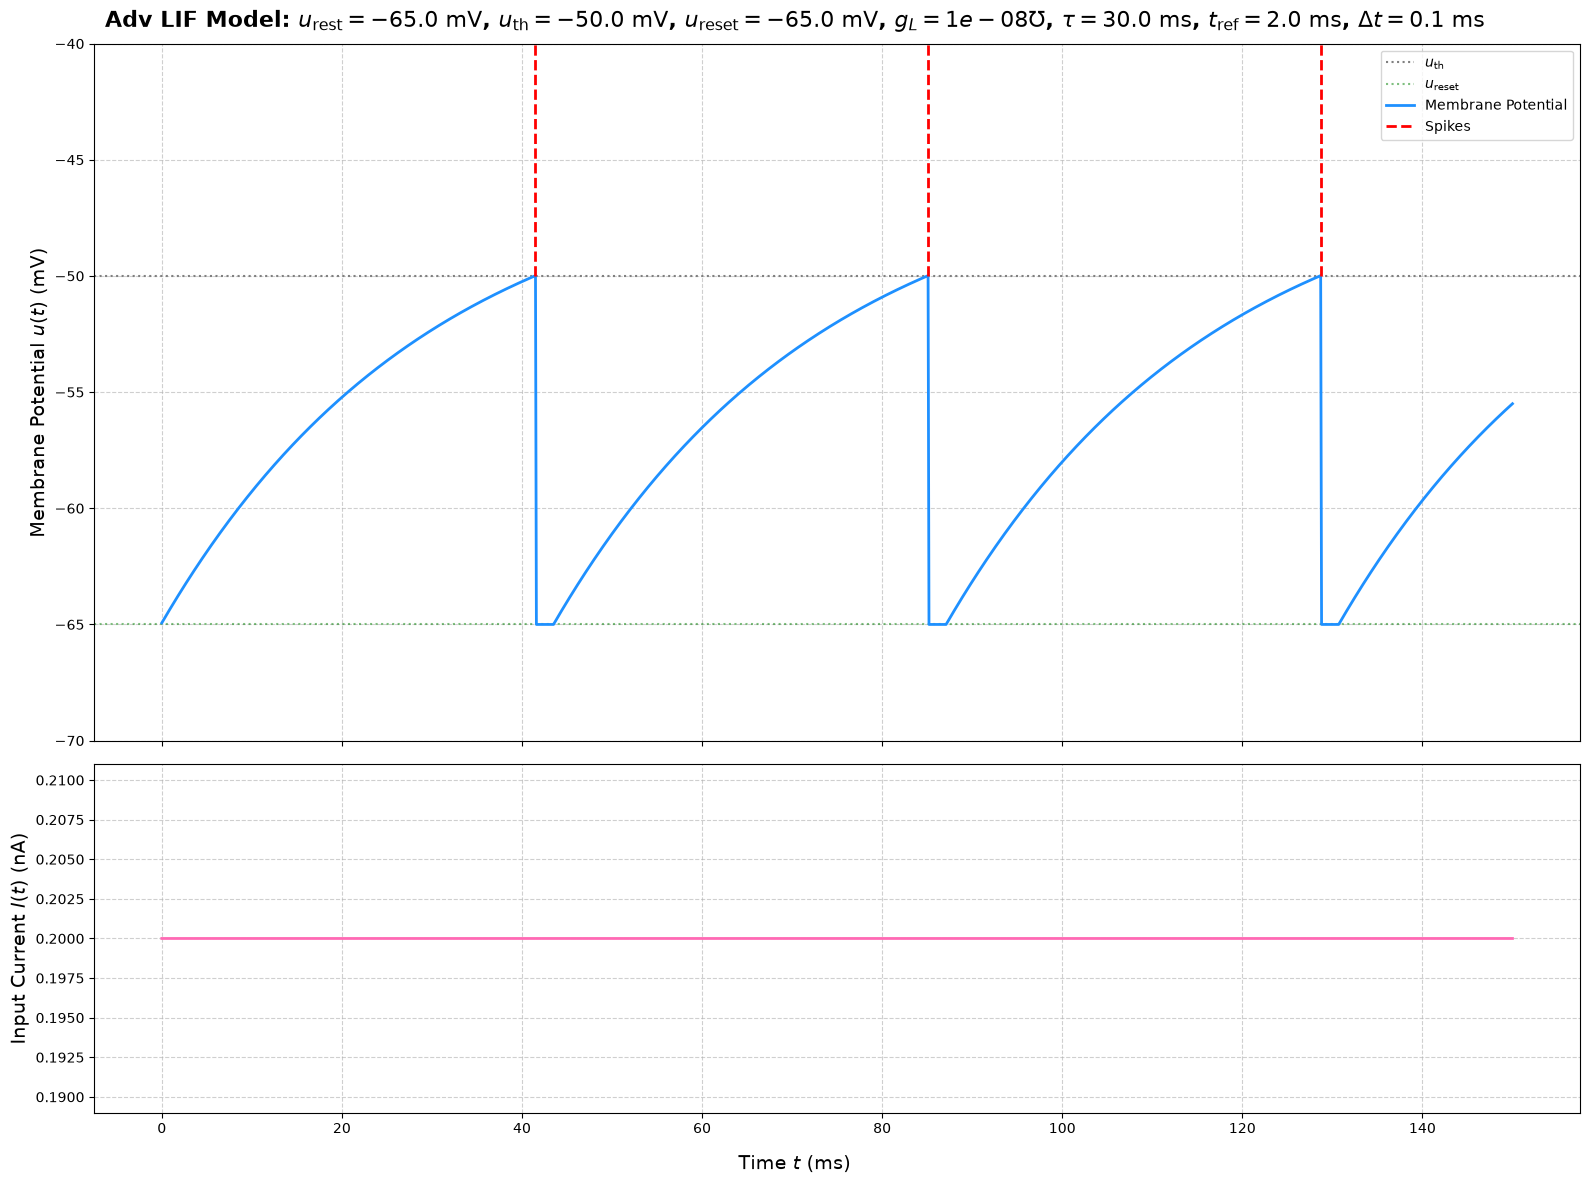

Inter Spike Time for tau=0.03 is 0.04360000000000099
Firing rate for tau=0.03 is 22.93577981651324


In [118]:
for tau in np.array([10, 20, 30]) * 1e-3:
    U, I, T, spikes = simulate_adv_lif(u_rest, u_th, u_reset, gL, tau, I_t, t_ref, delta_t, 0, 0.15)
    plot_membrane_potential(U, I, T, spikes, f"./q3_3/tau_{tau}.png")
    T_isi = np.mean(np.diff(T[spikes==True]))
    firing_rate = 1 / T_isi
    print(f"Inter Spike Time for tau={tau} is {T_isi}")
    print(f"Firing rate for tau={tau} is {firing_rate}")

# 4 : Input-Output Relationship

In [119]:
u_rest = -65 * 1e-3
u_th = -50 * 1e-3
u_reset = -65 * 1e-3
gL = 1e-8
tau = 2 * 1e-2
t_ref = 2 * 1e-3
delta_t = 1e-4

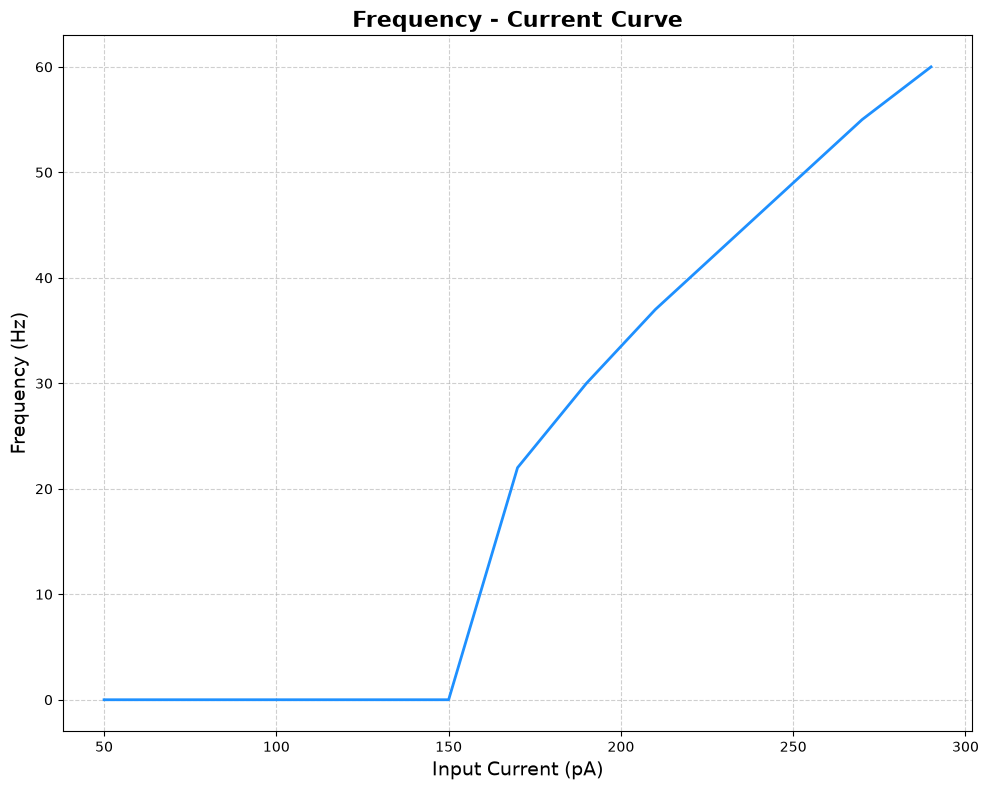

In [120]:
I = np.array(range(50, 300 + 1, 20))
F = []
for I_0 in I:
    I_t = lambda t, I_0=I_0: I_0 * 1e-12
    U, _, T, spikes = simulate_adv_lif(u_rest, u_th, u_reset, gL, tau, I_t, t_ref, delta_t, 0, 1)
    F.append(sum(spikes))

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(I, F, lw=2, c="dodgerblue")
ax.set_ylabel("Frequency (Hz)", fontsize=14)
ax.set_xlabel("Input Current (pA)", fontsize=14)
ax.set_title("Frequency - Current Curve", fontsize=16, fontweight='bold')
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
fig.savefig("./freq_current.png", dpi=500)
plt.show(fig)

### Evolution of Firing Rate with Increasing Input Current ($I_0$)

The relationship between input current $I_0$ and firing rate $f(I_0)$ (the **F-I curve**) exhibits three distinct regimes:

#### 1. Below Rheobase ($I_0 < I_{\text{rheo}}$) — Quiescent / Subthreshold Regime
* **Firing Rate:** $f = 0\text{ Hz}$.
* The steady-state potential $u_\infty = u_{\text{rest}} + \frac{I_0}{g_L}$ remains below the threshold $u_{\text{th}}$. No action potentials are generated.

---

#### 2. Just Above Rheobase ($I_0 \gtrsim I_{\text{rheo}}$) — Onset of Firing (Continuous Class 1 Excitability)
* **Firing Rate:** Emerges continuously from **$0\text{ Hz}$** and rises steeply.
* Near threshold, the charging time exhibits a **logarithmic singularity**:
  $$T_{\text{charge}} = \tau \ln\left(\frac{I_0 - g_L(u_{\text{reset}} - u_{\text{rest}})}{I_0 - I_{\text{rheo}}}\right) = \tau \ln\left(\frac{I_0}{I_0 - I_{\text{rheo}}}\right) \approx \tau \ln\left(\frac{I_{\text{rheo}}}{I_0 - I_{\text{rheo}}}\right)$$
* As $I_0 \to I_{\text{rheo}}^+$, the denominator $(I_0 - I_{\text{rheo}}) \to 0^+$, which causes the charging time to diverge ($T_{\text{charge}} \to \infty$).
* Consequently, the latency to fire diverges, resulting in arbitrarily low firing frequencies ($f \to 0^+$), characteristic of a **Saddle-Node on Invariant Circle (SNIC) bifurcation / Type 1 excitability**.


---

#### 3. Moderate to High Currents ($I_0 \gg I_{\text{rheo}}$) — Linear Growth & Saturation
* **Moderate Currents:** The charging time decreases rapidly with current ($T_{\text{charge}} \propto \frac{1}{I_0}$), leading to a nearly linear increase in firing rate with input current.
* **Very High Currents ($I_0 \to \infty$):** 
  * The charging time becomes negligible ($T_{\text{charge}} \to 0$) compared to the absolute refractory period $t_{\text{ref}}$.
  * The inter-spike interval asymptotically approaches $T_{\text{ISI}} \approx t_{\text{ref}}$.
  * The firing rate **saturates at a maximum upper limit**:
    $$f_{\text{max}} = \frac{1}{t_{\text{ref}}} = \frac{1}{2\text{ ms}} = 500\text{ Hz}$$


## 5 : Effect of Noise on Spike Timing

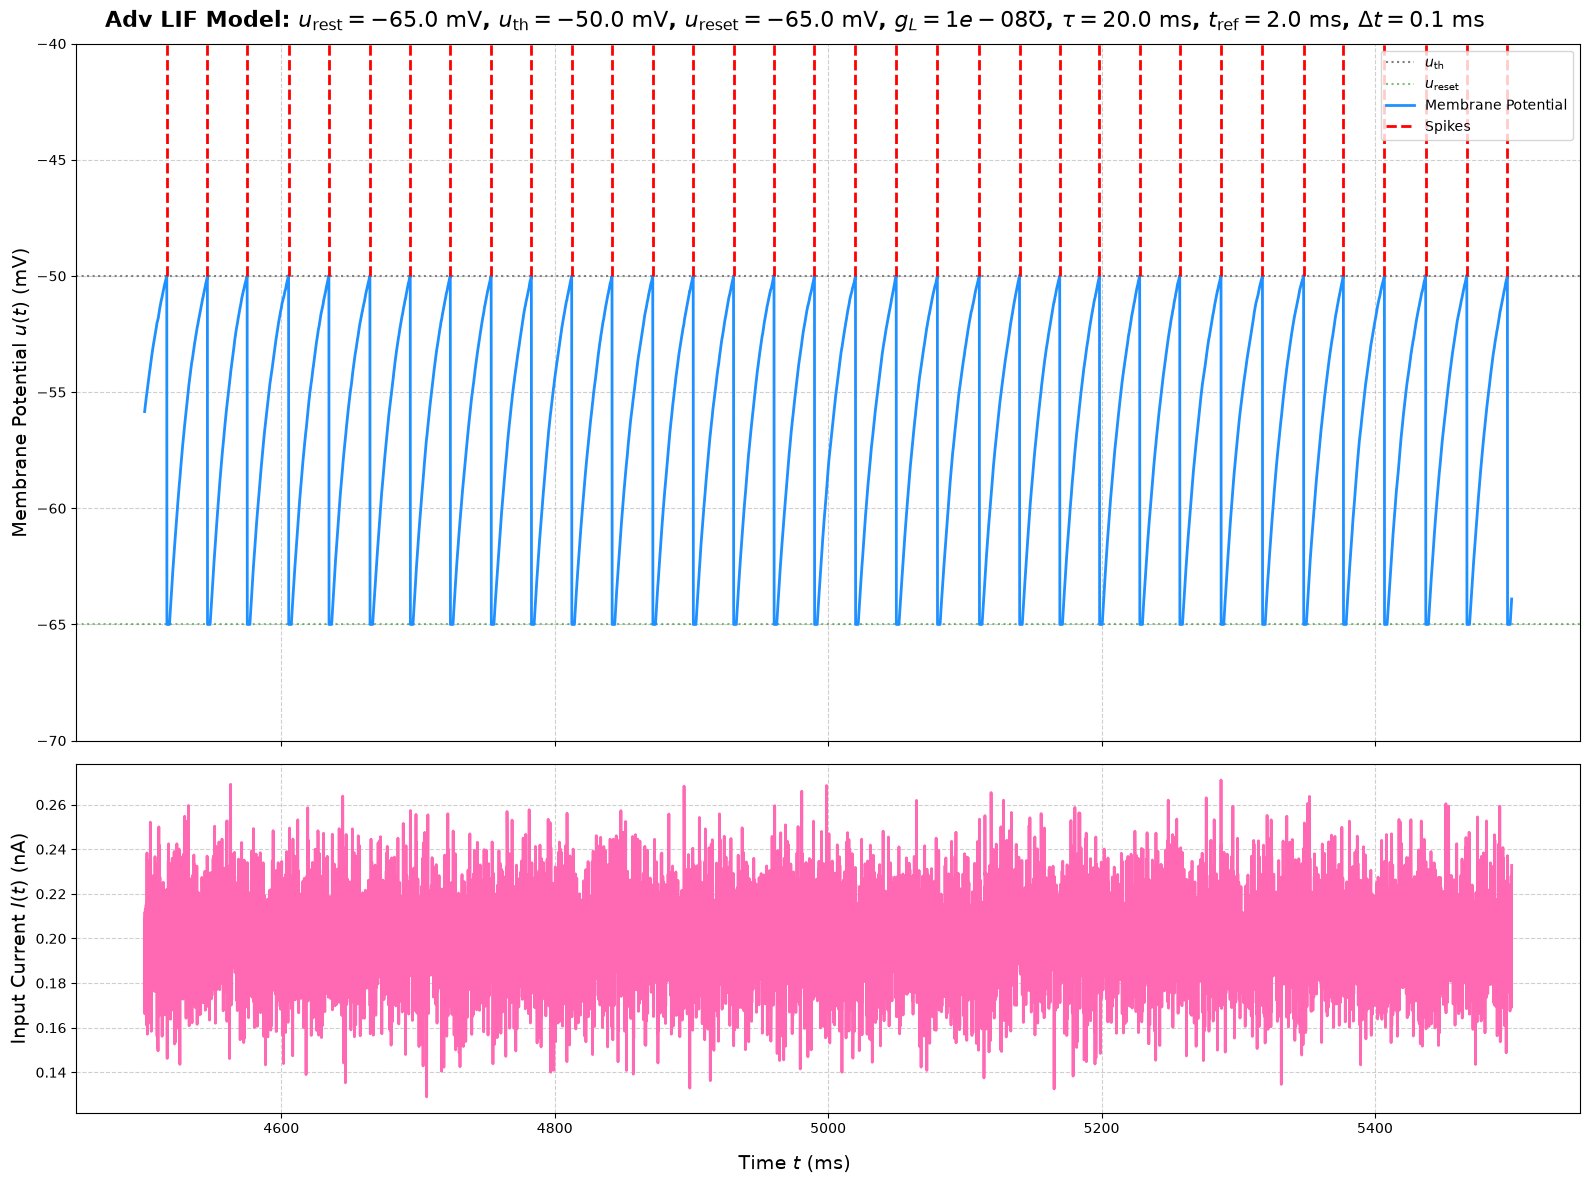

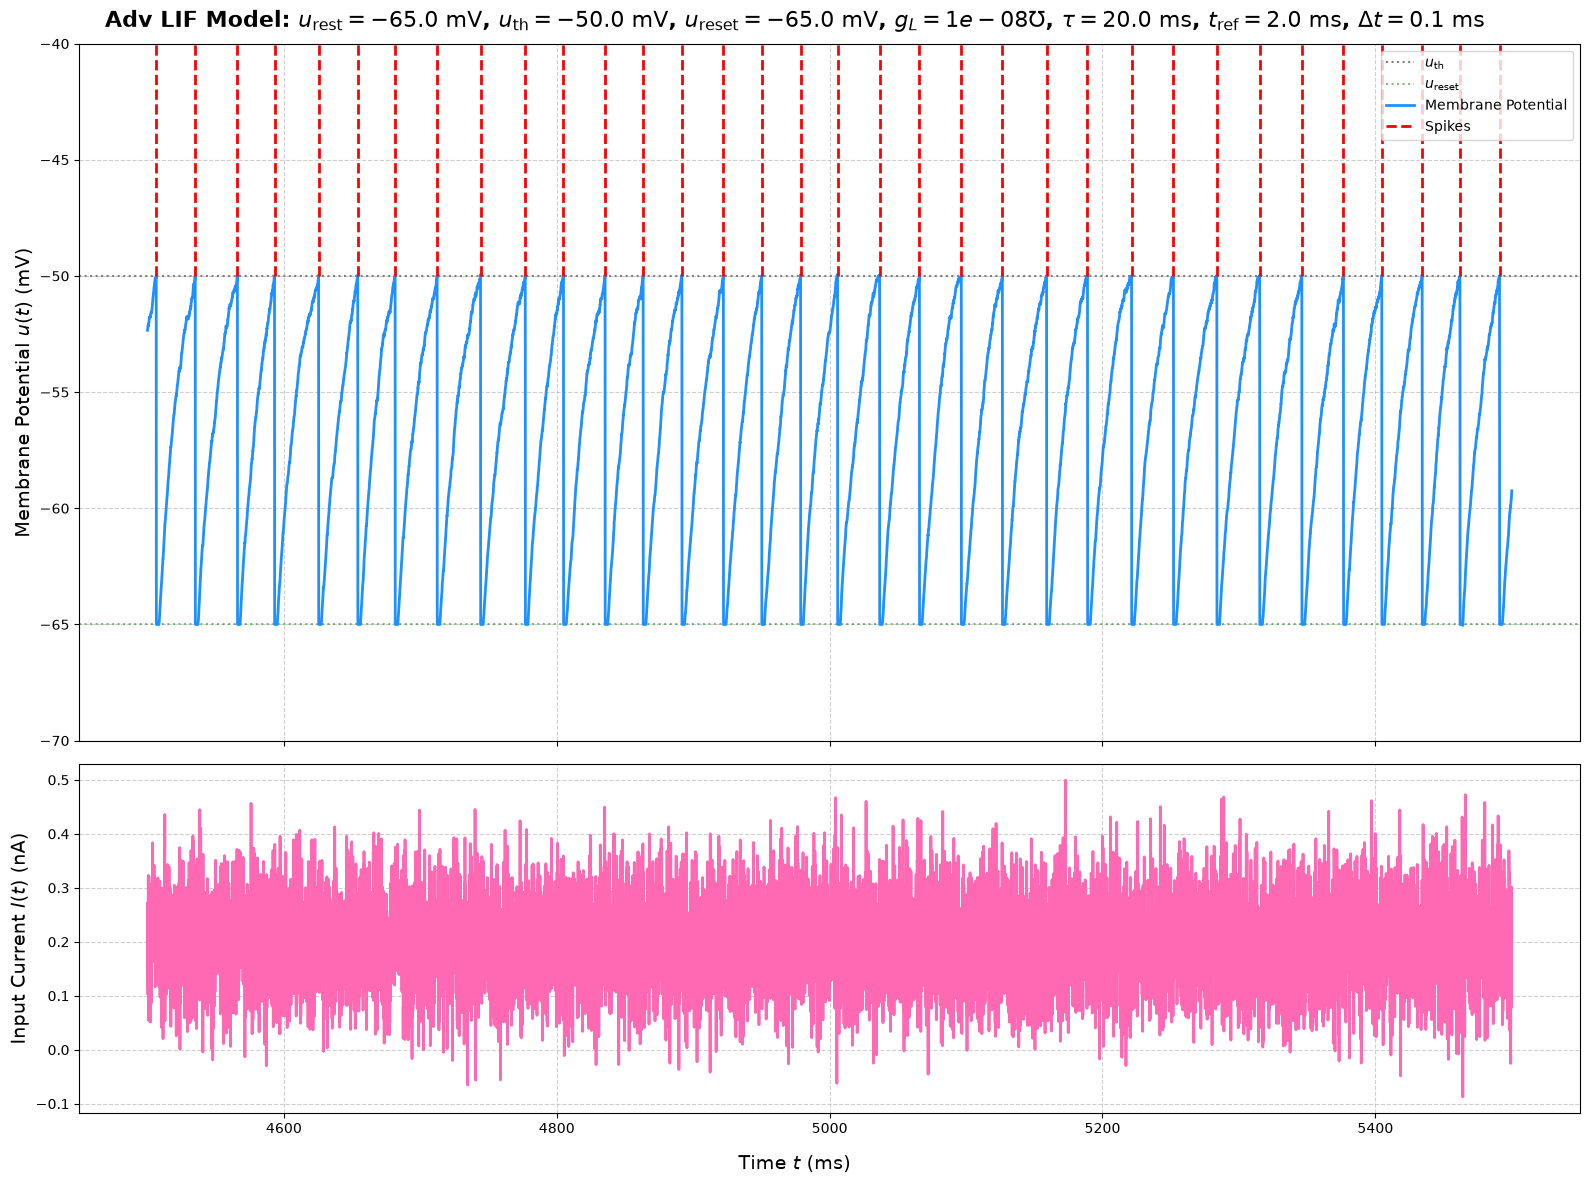

Coefficient of Variation for sigma = 20:  0.012680311725143783
Coefficient of Variation for sigma = 80:  0.054097097670742736


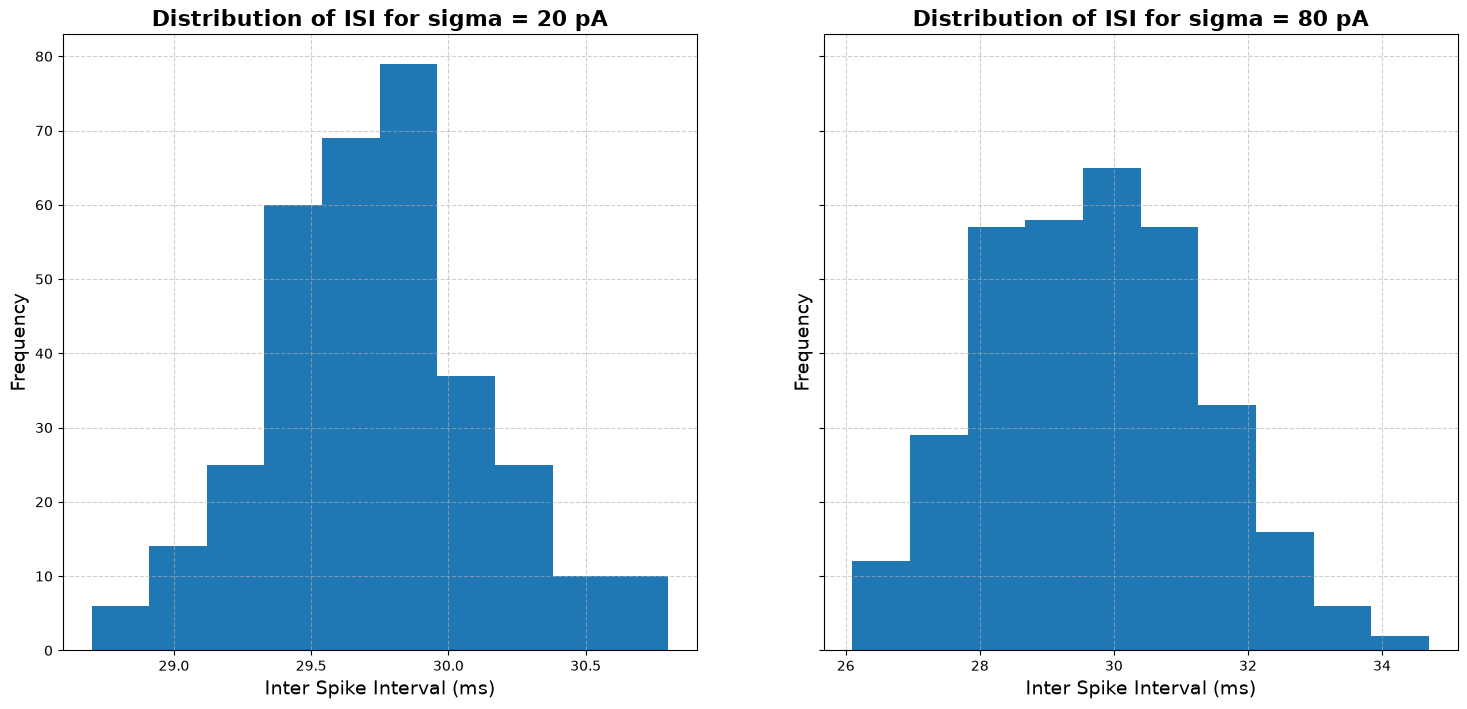

In [122]:
for i, sigma in enumerate([20, 80]):
    I_t = lambda t, sigma=sigma: (200 + sigma * np.random.standard_normal()) * 1e-12
    U, I, T, spikes = simulate_adv_lif(u_rest, u_th, u_reset, gL, tau, I_t, t_ref, delta_t, 0, 10)
    plot_membrane_potential(U[45000:55001], I[45000:55001], T[45000:55001], spikes[45000:55001], f"./q3_5/plots/sigma_{sigma}.png")
    np.savetxt(f"./q3_5/traces/sigma_{sigma}.txt", U)
    np.savetxt(f"./q3_5/spikes/sigma_{sigma}.txt", spikes)

fig, ax = plt.subplots(1,2, figsize=(18, 8), sharey=True)
for i, sigma in enumerate([20, 80]):
    T = np.linspace(0, 10, 100001)
    spikes = np.loadtxt(f"./q3_5/spikes/sigma_{sigma}.txt")
    ISI = np.diff(T[spikes==True]) * 1e3
    ISI_cv = np.std(ISI) / np.mean(ISI)
    print(f"Coefficient of Variation for sigma = {sigma}: ", ISI_cv)   
    ax[i].hist(ISI)
    ax[i].set_ylabel("Frequency", fontsize=14)
    ax[i].set_xlabel("Inter Spike Interval (ms)", fontsize=14)
    ax[i].set_title(f"Distribution of ISI for sigma = {sigma} pA", fontsize=16, fontweight='bold')
    ax[i].grid(True, linestyle="--", alpha=0.6)
fig.savefig("./histograms.png", dpi=500)
plt.show(fig)

---